# Tuning hyperparameters

Set directory

In [1]:
import sys
import os

# Find the project root (Speciale_Kode)
current_dir = os.getcwd()
project_root = current_dir

# Looks for "Speciale_Kode" folder:
while os.path.basename(project_root) != "Speciale_Kode":
    project_root = os.path.dirname(project_root)

# Add to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

Load data:

In [2]:
from Modules.read_data import read_data
import pandas as pd
from pathlib import Path

(
    DK1_train,
    DK1_test,
    DK2_train,
    DK2_test,
    DK1_train_weather,
    DK1_test_weather,
    DK2_train_weather,
    DK2_test_weather
) = read_data("combined_data_cleaned_v5.csv")
print(f"Features: {DK1_train.columns.tolist()}")

def _load_feature_predictions_for_zone(zone):
    prediction_path = Path(project_root) / "Data" / f"feature_predictions_{zone}_2024-2025.csv"
    if not prediction_path.exists():
        print("No precomputed forecasts found.")
        return None

    predictions = pd.read_csv(prediction_path, decimal=",", sep = ";", parse_dates=["Time"])
    predictions = predictions.loc[:, ~predictions.columns.duplicated()].copy()
    if "DKZone" in predictions.columns:
        predictions = predictions.loc[predictions["DKZone"] == zone].copy()
    return predictions


dk1_feature_predictions = _load_feature_predictions_for_zone("DK1")
dk2_feature_predictions = _load_feature_predictions_for_zone("DK2")
if (dk1_feature_predictions is not None) and (dk2_feature_predictions is not None):
    print("\nPrecomputed forecasts loaded.")

dk1_use_precomputed_feature_values = dk1_feature_predictions is not None
dk2_use_precomputed_feature_values = dk2_feature_predictions is not None

Notebook_dir: c:\Users\Christine\Documents\Python\Speciale_Kode\Modules
Python_dir: c:\Users\Christine\Documents\Python\Speciale_Kode
Data_folder: c:\Users\Christine\Documents\Python\Speciale_Kode\Data
Training data shape (DK1): (78888, 38)
Test data shape (DK1): (8760, 38)
Test set fraction (DK1): 9.99%
Training data shape (DK2): (78888, 38)
Test data shape (DK2): (8760, 38)
Test set fraction (DK2): 9.99%
Features: ['DKPrice', 'Time', 'OffshoreWindPower', 'OnshoreWindPower', 'HydroPower', 'SolarPower', 'Biomass', 'Biogas', 'Waste', 'FossilGas', 'FossilOil', 'FossilHardCoal', 'ExchangeGreatBelt', 'ExchangeGermany', 'ExchangeSweden', 'ExchangeNorway', 'ExchangeNetherlands', 'WindSpeed', 'Radiation', 'DEPrice', 'NO2Price', 'SE3Price', 'SE4Price', 'NLPrice', 'GrossCon', 'TotalProduction', 'Year', 'Month', 'Day', 'WeekDay', 'Hour', 'OffshoreWindCapacity', 'OnshoreWindCapacity', 'SolarPowerCapacity', 'GrossCon_lag1', 'GrossCon_lag24', 'Price_lag1', 'Price_lag24']

Precomputed forecasts load

## Choose validation setup


**Setup 1**

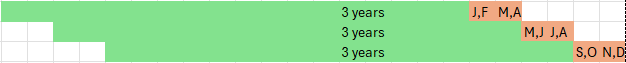

For this setup, val_start in the first fold is fixed at 2024-01-01 00:00:00 and train_end the hour before that (2023-12-31 23:00:00). train_start, val_end and remaining fold values are computed using train_window, predict_horizon and stride.

**Setup 2**



For this setup, val_end in the first fold is fixed at 2024-12-31 23:00:00. train_start, train_end and val_start are computed using train_window and predict_horizon. There is only one fold, so stride has no function.

Write the desired setup number as "split_setup" in the hyper_param_split() function below.

In [3]:
setup = 2

Import models

In [4]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
# Import model library. E.g.:
# from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from Modules.Load_RF_forecast_models import load_rf_models

rf_models = None
if not (dk1_use_precomputed_feature_values and dk2_use_precomputed_feature_values):
    # load_rf_models currently supports only the optional timeout argument.
    rf_models = load_rf_models(user="Christine - laptop")      # set user to "Nikolaj" or "Christine"


In [5]:
from skforecast.exceptions import IgnoredArgumentWarning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Raw feature columns are present")
warnings.filterwarnings("ignore", category=UserWarning, message="Some categorized features not in dataset")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names")
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

Make train and test periods

In [6]:
import pandas as pd
from Modules.Validation2 import _build_validation_folds

price_zone = "DK1"
if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

dataset = pd.concat([train_data, test_data], ignore_index=True)

folds = _build_validation_folds(
    data=dataset,
    train_window=2*8760+8784,        
    val_window=len(test_data),
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data),         # 168 hours = 1 week
    stride=len(test_data),               # stride between predict_periods              
)

train_start = folds[0]["train_start"]
train_end = folds[0]["train_end"]
num_folds = len(folds)
val_start = folds[0]["val_start"]
val_end = val_start + pd.Timedelta(hours=len(test_data) - 1)
prediction_period = folds[0]["val_end"] - folds[0]["val_start"] + pd.Timedelta(hours=1)

print(f"Fold {folds[0]['fold']} train start: {train_start} - train end: {train_end}")
print(f"Number of folds: {num_folds}")
print(f"Test window start: {val_start} - test window end: {val_end}")
print(f"Prediction period: {prediction_period}")
for fold in range(len(folds)):
    print(f"Fold {folds[fold]['fold']} test start: {folds[fold]['val_start']} - test end: {folds[fold]['val_end']}")

Fold 1 train start: 2022-01-01 00:00:00 - train end: 2024-12-31 23:00:00
Number of folds: 1
Test window start: 2025-01-01 00:00:00 - test window end: 2025-12-31 23:00:00
Prediction period: 365 days 00:00:00
Fold 1 test start: 2025-01-01 00:00:00 - test end: 2025-12-31 23:00:00


c:\Users\Christine\anaconda3\envs\ds809\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Train and test the final model

## Random Forest

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from sklearn.ensemble import RandomForestRegressor

# Initialize model:
model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    'n_estimators': 200,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


# Save model in the same folder as this notebook/script
model_dir = Path(project_root) / "Shallow learners" / "Final_eval" / "Shap"
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / f"Random_forest_final_model_{price_zone}.joblib"

results = []

model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "Shap")
base_filename = f"{price_zone}_RF_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = f"{base_filename}_{counter}.csv"
    filename = os.path.join(folder, filename)
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_RF_predictions.csv"),
    index=False,
    decimal=","
)

joblib.dump(model, model_path, compress=3)
print(f"Trained model saved to: {model_path}")

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from sklearn.ensemble import RandomForestRegressor

# Initialize model:
model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    'n_estimators': 50,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 10
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)

# Save model in the same folder as this notebook/script
model_dir = Path(project_root) / "Shallow learners" / "Final_eval" / "Shap"
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / f"Random_forest_final_model_{price_zone}.joblib"

results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "Shap")
base_filename = f"{price_zone}_RF_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = f"{base_filename}_{counter}.csv"
    filename = os.path.join(folder, filename)
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_RF_predictions.csv"),
    index=False,
    decimal=","
)

joblib.dump(model, model_path, compress=3)
print(f"Trained model saved to: {model_path}")


Running SHAP analysis for DK1
Loaded model from disk: c:\Users\Christine\Documents\Python\Speciale_Kode\Shallow learners\Final_eval\Shap\Random_forest_final_model_DK1.joblib
Using fitted Random Forest with 200 trees
Available RAM before SHAP: 3.23 GB
Training set size for SHAP: 26304 samples
Number of features: 36

Background sample size (X_bg): 1000
Evaluation sample size (X_eval): 2000
Chunk size: 10
Computing SHAP chunk 1/200 (rows 0:10)...
Computing SHAP chunk 2/200 (rows 10:20)...
Computing SHAP chunk 3/200 (rows 20:30)...
Computing SHAP chunk 4/200 (rows 30:40)...
Computing SHAP chunk 5/200 (rows 40:50)...
Computing SHAP chunk 6/200 (rows 50:60)...
Computing SHAP chunk 7/200 (rows 60:70)...
Computing SHAP chunk 8/200 (rows 70:80)...
Computing SHAP chunk 9/200 (rows 80:90)...
Computing SHAP chunk 10/200 (rows 90:100)...
Computing SHAP chunk 11/200 (rows 100:110)...
Computing SHAP chunk 12/200 (rows 110:120)...
Computing SHAP chunk 13/200 (rows 120:130)...
Computing SHAP chunk 14/

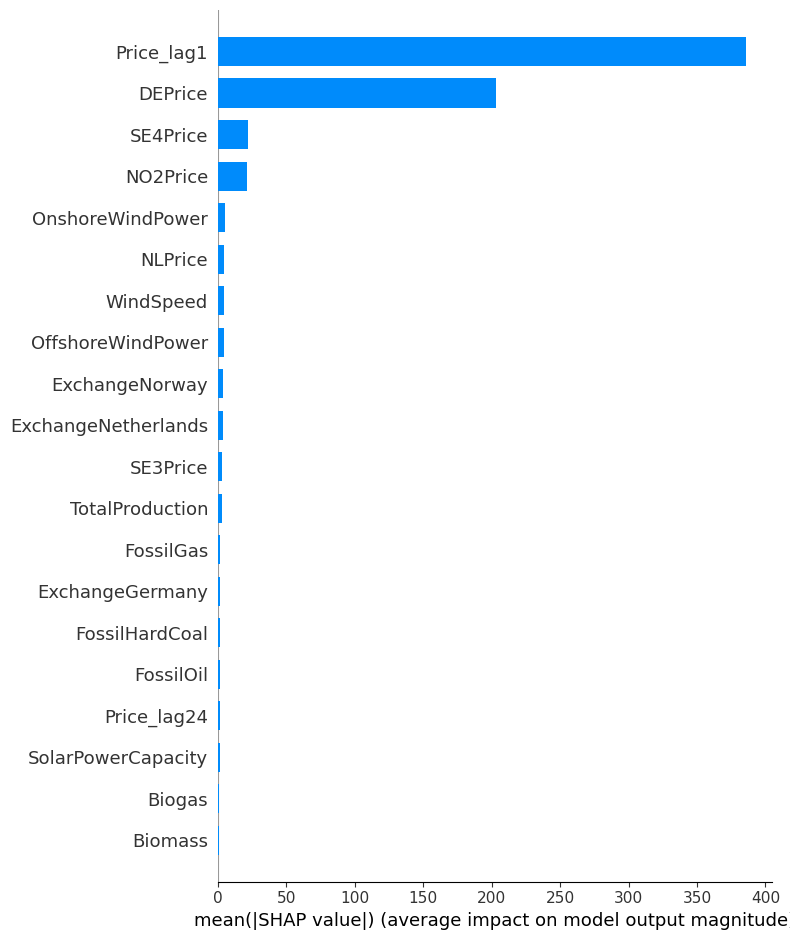

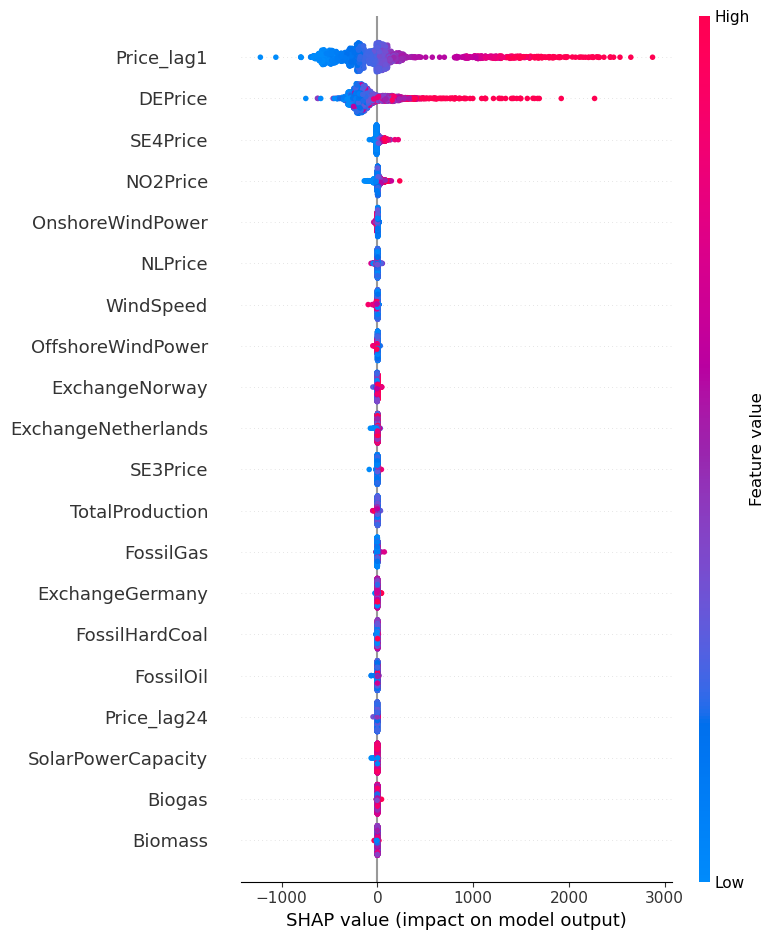

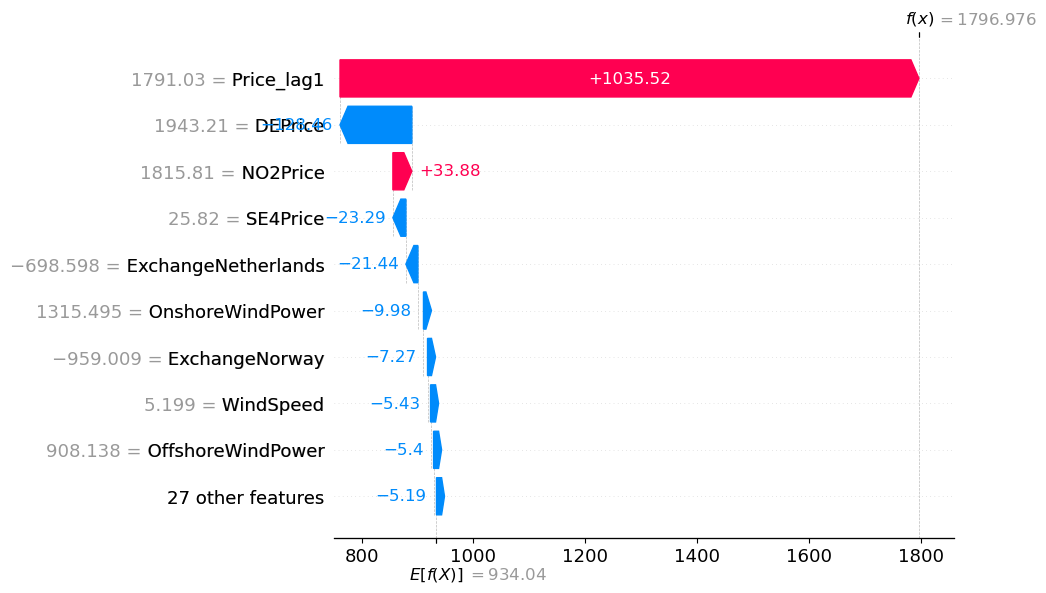

<Figure size 640x480 with 0 Axes>

Available RAM while running SHAP: 2.35 GB

Running SHAP analysis for DK2
Loaded model from disk: c:\Users\Christine\Documents\Python\Speciale_Kode\Shallow learners\Final_eval\Shap\Random_forest_final_model_DK2.joblib
Using fitted Random Forest with 50 trees
Available RAM before SHAP: 2.75 GB
Training set size for SHAP: 26304 samples
Number of features: 36

Background sample size (X_bg): 1000
Evaluation sample size (X_eval): 2000
Chunk size: 10
Computing SHAP chunk 1/200 (rows 0:10)...
Computing SHAP chunk 2/200 (rows 10:20)...
Computing SHAP chunk 3/200 (rows 20:30)...
Computing SHAP chunk 4/200 (rows 30:40)...
Computing SHAP chunk 5/200 (rows 40:50)...
Computing SHAP chunk 6/200 (rows 50:60)...
Computing SHAP chunk 7/200 (rows 60:70)...
Computing SHAP chunk 8/200 (rows 70:80)...
Computing SHAP chunk 9/200 (rows 80:90)...
Computing SHAP chunk 10/200 (rows 90:100)...
Computing SHAP chunk 11/200 (rows 100:110)...
Computing SHAP chunk 12/200 (rows 110:120)...
Computing SHAP chunk 13/200 (

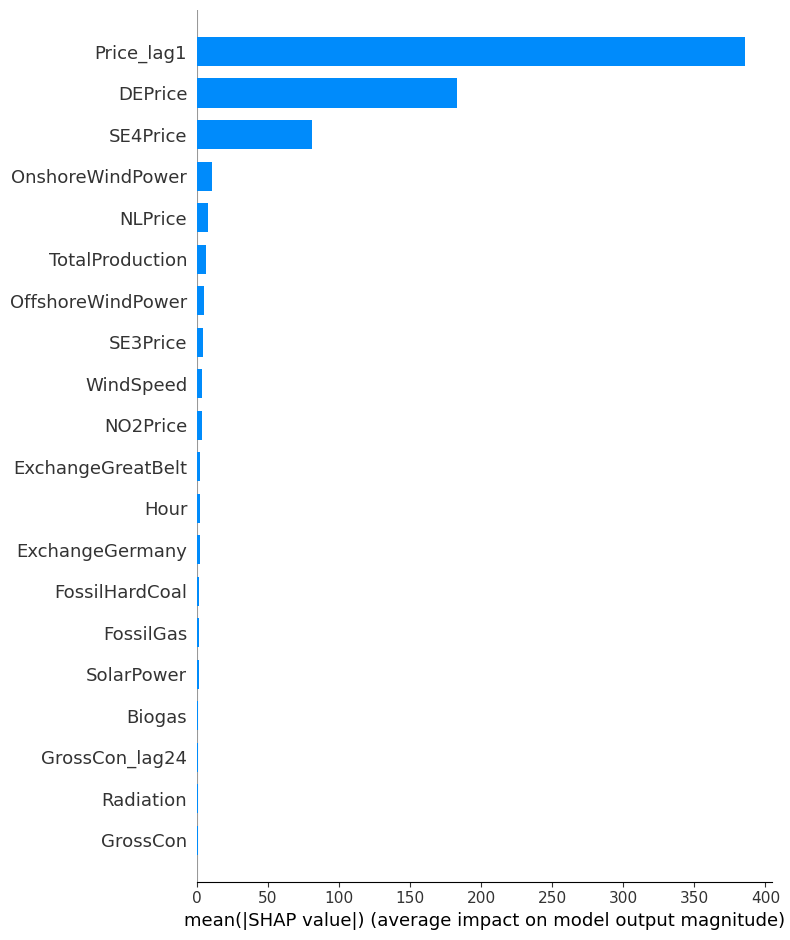

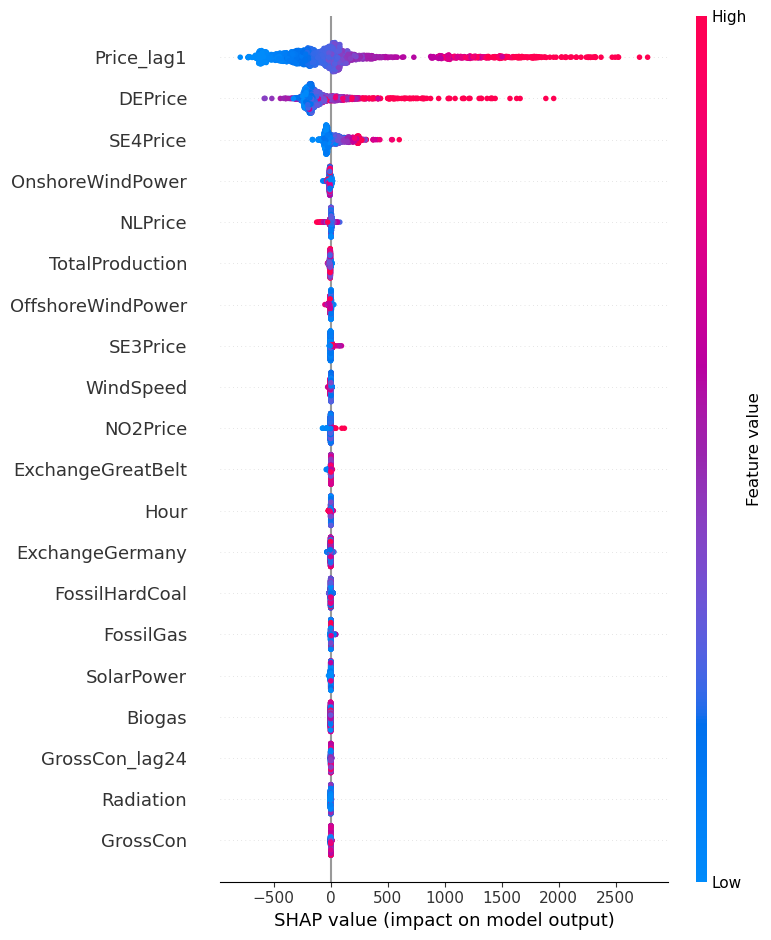

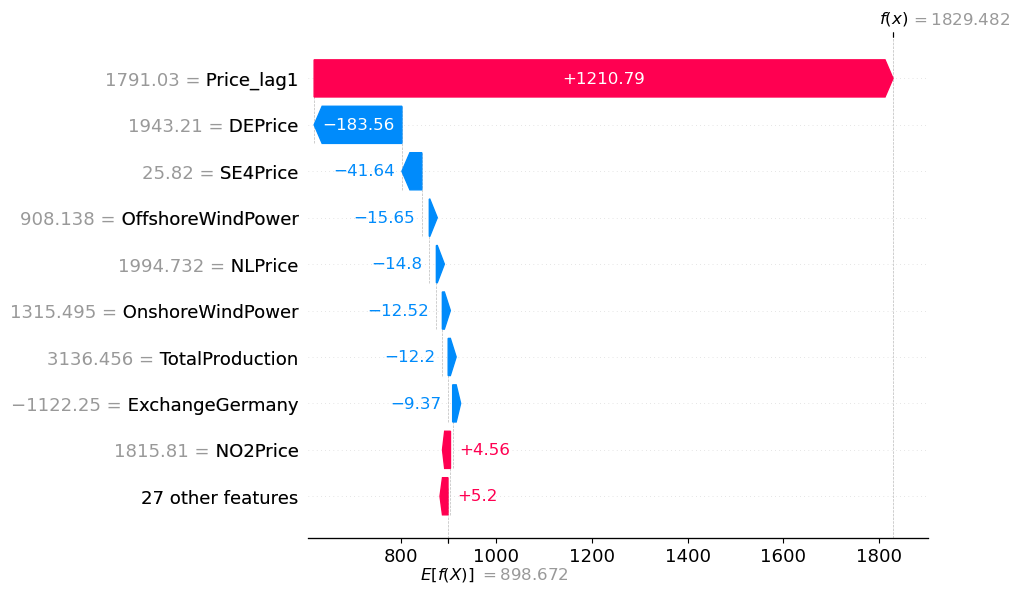

<Figure size 640x480 with 0 Axes>

Available RAM while running SHAP: 3.19 GB
Available RAM after SHAP cleanup: 3.20 GB


In [7]:
import gc
from pathlib import Path
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

# ==========================
# SHAP configuration (easy to tune)
# ==========================
quick_mode = False
eval_size = 2000            # <- Evaluation sample size: number of rows to analyse
bg_size = 1000              # <- Background sample size: used to compute expected values
chunk_size = 10             # <- Lower if memory issues
include_beeswarm = True
include_waterfall = True
joblib_file = "Random_forest_final_model_*.joblib"  # Fallback search pattern in current folder

model_name = "RandomForest"

save_dir = Path(project_root) / "Shallow learners" / "Final_eval" / "Shap" / "plots"
save_dir.mkdir(parents=True, exist_ok=True)

for price_zone in ["DK1", "DK2"]:
    print(f"\n{'='*50}\nRunning SHAP analysis for {price_zone}\n{'='*50}")

    # Auto-load model if it is missing from memory
    if "model" not in globals():
        if "project_root" not in globals():
            raise ValueError("Missing 'project_root'. Run 'Set directory' cell first.")

        model_dir = Path(project_root) / "Shallow learners" / "Final_eval" / "Shap"
        model_path = None

        # Prefer current price_zone if available
        if "price_zone" in globals():
            preferred = model_dir / f"Random_forest_final_model_{price_zone}.joblib"
            if preferred.exists():
                model_path = preferred

        # Otherwise load the newest .joblib that matches the pattern
        if model_path is None:
            candidates = sorted(model_dir.glob(joblib_file), key=lambda p: p.stat().st_mtime, reverse=True)
            if candidates:
                model_path = candidates[0]

        if model_path is None or not model_path.exists():
            raise ValueError(f"No .joblib model found in {model_dir}. Train once or place model file there.")

        model = joblib.load(model_path)
        print(f"Loaded model from disk: {model_path}")

    required_vars = ["dataset", "folds"]
    missing = [v for v in required_vars if v not in globals()]
    if missing:
        raise ValueError(
            f"Missing required variables: {missing}. Run 'Make train and test periods' cell first."
        )

    # Confirm model is fitted (LightGBM exposes booster_ after fit)
    if not hasattr(model, "estimators_") or not model.estimators_:
        raise ValueError("Loaded model is not fitted. Train final model first.")
    print(f"Using fitted Random Forest with {len(model.estimators_)} trees")

    # Rebuild the same training frame used for fitting
    data = dataset.copy().sort_values("Time").reset_index(drop=True)
    feature_columns = [c for c in data.columns[1:] if c != "Time"]

    first_fold = folds[0]
    train_mask = (data["Time"] >= first_fold["train_start"]) & (data["Time"] <= first_fold["train_end"])
    X_train_shap = data.loc[train_mask, feature_columns].copy()

    if len(X_train_shap) == 0:
        raise ValueError("No rows found for SHAP training slice. Check folds and dataset alignment.")

    # Downcast to reduce memory pressure
    X_train_shap = X_train_shap.astype(np.float32, copy=False)

    mem = psutil.virtual_memory()
    print(f"Available RAM before SHAP: {mem.available / (1024**3):.2f} GB")
    print(f"Training set size for SHAP: {len(X_train_shap)} samples")
    print(f"Number of features: {len(feature_columns)}")

    if quick_mode:
        bg_size = min(20, len(X_train_shap))
        eval_size = min(40, len(X_train_shap))
        chunk_size = 5
    else:
        bg_size = min(bg_size, len(X_train_shap))
        eval_size = min(eval_size, len(X_train_shap))
        chunk_size = max(1, min(chunk_size, eval_size))

    X_bg = shap.sample(X_train_shap, bg_size, random_state=42)
    X_eval = shap.sample(X_train_shap, eval_size, random_state=42)

    print(f"\nBackground sample size (X_bg): {len(X_bg)}")
    print(f"Evaluation sample size (X_eval): {len(X_eval)}")
    print(f"Chunk size: {chunk_size}")

    explainer = shap.TreeExplainer(
        model,
        feature_perturbation="tree_path_dependent",
        model_output="raw"
    )

    # Compute SHAP values in chunks and print progress
    shap_chunks = []
    n_chunks = (len(X_eval) + chunk_size - 1) // chunk_size
    for idx, start in enumerate(range(0, len(X_eval), chunk_size), start=1):
        stop = min(start + chunk_size, len(X_eval))
        print(f"Computing SHAP chunk {idx}/{n_chunks} (rows {start}:{stop})...", flush=True)
        X_chunk = X_eval.iloc[start:stop]
        shap_chunk = explainer.shap_values(
            X_chunk,
            check_additivity=False
        )
        shap_chunks.append(shap_chunk)

    shap_values = np.vstack(shap_chunks)
    gc.collect()

    print("\nSHAP analysis complete.")

    # Global importance
    plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values, X_eval, plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig(save_dir / f"shap_bar_{model_name}_{price_zone}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    if include_beeswarm:
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_eval, show=False)
        plt.tight_layout()
        plt.savefig(save_dir / f"shap_beeswarm_{model_name}_{price_zone}.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

    if include_waterfall:
        i = 0
        base_value = explainer.expected_value
        if isinstance(base_value, (list, tuple, np.ndarray)):
            base_value = np.array(base_value).reshape(-1)[0]

        plt.figure(figsize=(10, 4))
        shap.plots.waterfall(
            shap.Explanation(
                values=shap_values[i],
                base_values=base_value,
                data=X_eval.iloc[i].values,
                feature_names=X_eval.columns.tolist()
            )
        )
        plt.tight_layout()
        plt.savefig(save_dir / f"shap_waterfall_{model_name}_{price_zone}.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

    mem_while_running = psutil.virtual_memory()
    print(f"Available RAM while running SHAP: {mem_while_running.available / (1024**3):.2f} GB")

    # Cleanup large objects explicitly
    del model
    gc.collect()

mem_after = psutil.virtual_memory()
print(f"Available RAM after SHAP cleanup: {mem_after.available / (1024**3):.2f} GB")

## LightGBM

In [8]:
numeric_cols = feature_predictions.columns.difference(["Time", "DKZone"])
feature_predictions[numeric_cols] = feature_predictions[numeric_cols].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(",", "."), errors="coerce")
)

NameError: name 'feature_predictions' is not defined

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006170 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7294
[LightGBM] [Info] Number of data points in the train set: 26304, number of used features: 36
[LightGBM] [Info] Start training from score 934.022263
Model trained in 0.61s. Now validating on 1 folds...


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions.py:658: UserWarning: RF models not provided. Skipping RF feature forecast for 'OffshoreWindPower'. Pass rf_models parameter to get_predictions() to forecast RF features.
  warnings.warn(warn_msg)
c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions.py:658: UserWarning: RF models not provided. Skipping RF feature forecast for 'OnshoreWindPower'. Pass rf_models parameter to get_predictions() to forecast RF features.
  warnings.warn(warn_msg)
c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions.py:658: UserWarning: RF models not provided. Skipping RF feature forecast for 'SolarPower'. Pass rf_models parameter to get_predictions() to forecast RF features.
  warnings.warn(warn_msg)
c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions.py:658: UserWarning: RF models not provided. Skipping RF feature forecast for 'TotalProduction'. Pass rf_models paramete


Average RMSE across all weeks in all folds: 313.944

Average MAE across all weeks in all folds: 237.414

Average SMAPE across all weeks in all folds: 50.933


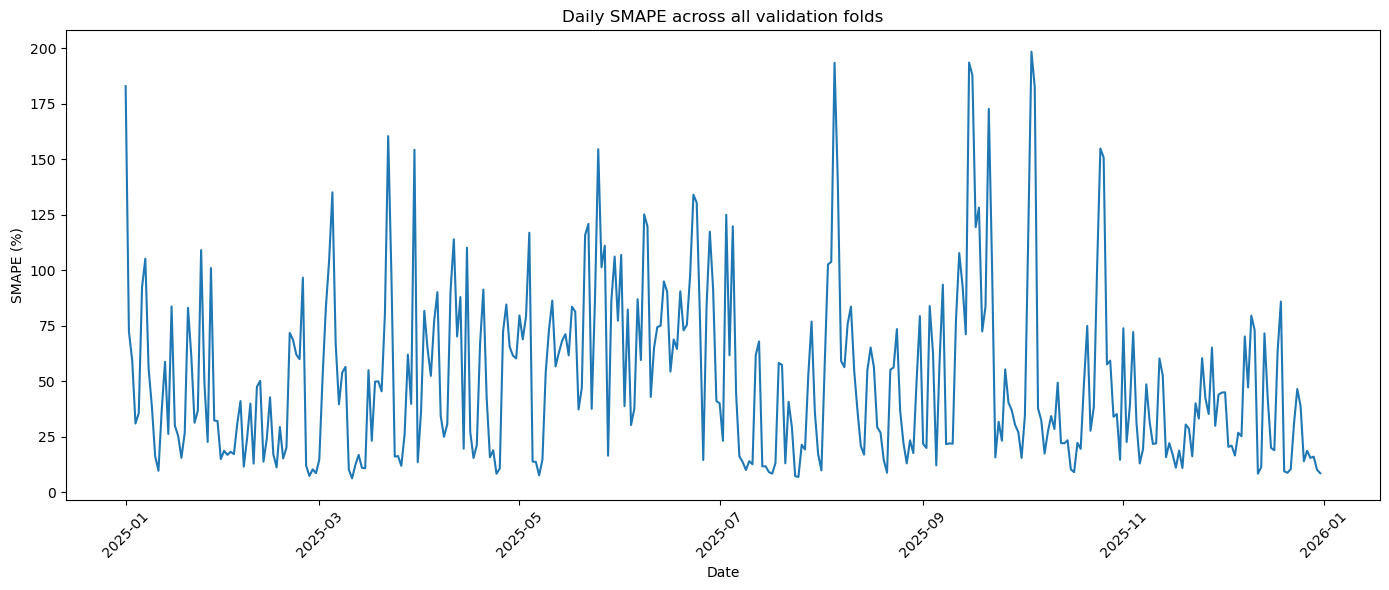

Trained model saved to: c:\Users\Christine\Documents\Python\Speciale_Kode\Shallow learners\Final_eval\Shap\LightGBM_final_model_DK1.joblib


In [9]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from lightgbm import LGBMRegressor

# Initialize model:
model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1
)

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "n_estimators": 200,
    "learning_rate": 0.01,
    "num_leaves": 15,            
    "max_depth": -1,
    "min_child_samples": 1,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 0.0
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)

numeric_cols = feature_predictions.columns.difference(["Time", "DKZone"])
feature_predictions[numeric_cols] = feature_predictions[numeric_cols].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(",", "."), errors="coerce")
)

# Save model in the same folder as this notebook/script
model_dir = Path(project_root) / "Shallow learners" / "Final_eval" / "Shap"
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / f"LightGBM_final_model_{price_zone}.joblib"

results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "Shap")
base_filename = f"{price_zone}_LightGBM_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = f"{base_filename}_{counter}.csv"
    filename = os.path.join(folder, filename)
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_LightGBM_predictions.csv"),
    index=False,
    decimal=","
)

joblib.dump(model, model_path, compress=3)
print(f"Trained model saved to: {model_path}")

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003277 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6509
[LightGBM] [Info] Number of data points in the train set: 26304, number of used features: 33
[LightGBM] [Info] Start training from score 898.735589
Model trained in 1.62s. Now validating on 1 folds...


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions.py:658: UserWarning: RF models not provided. Skipping RF feature forecast for 'OffshoreWindPower'. Pass rf_models parameter to get_predictions() to forecast RF features.
  warnings.warn(warn_msg)
c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions.py:658: UserWarning: RF models not provided. Skipping RF feature forecast for 'OnshoreWindPower'. Pass rf_models parameter to get_predictions() to forecast RF features.
  warnings.warn(warn_msg)
c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions.py:658: UserWarning: RF models not provided. Skipping RF feature forecast for 'SolarPower'. Pass rf_models parameter to get_predictions() to forecast RF features.
  warnings.warn(warn_msg)
c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions.py:658: UserWarning: RF models not provided. Skipping RF feature forecast for 'TotalProduction'. Pass rf_models paramete


Average RMSE across all weeks in all folds: 293.605

Average MAE across all weeks in all folds: 224.996

Average SMAPE across all weeks in all folds: 49.543


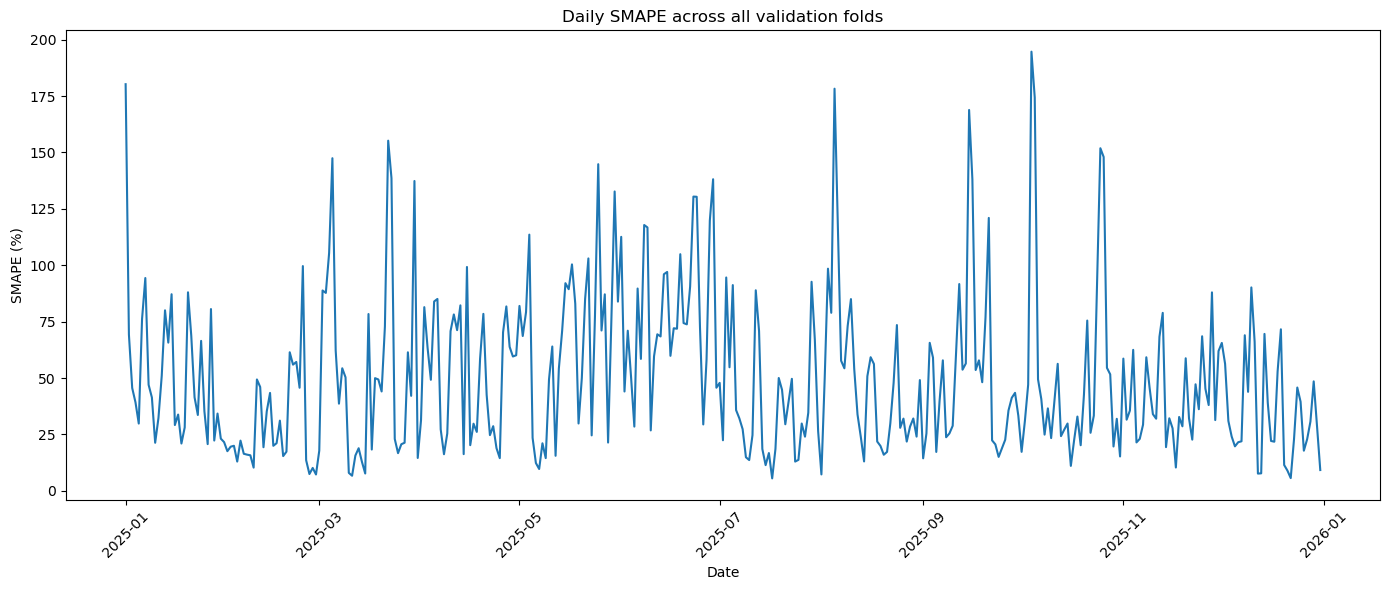

Trained model saved to: c:\Users\Christine\Documents\Python\Speciale_Kode\Shallow learners\Final_eval\Shap\LightGBM_final_model_DK2.joblib


In [10]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from lightgbm import LGBMRegressor

# Initialize model:
model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1
)

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "n_estimators": 200,
    "learning_rate": 0.01,
    "num_leaves": 127,            
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 0.0
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)

numeric_cols = feature_predictions.columns.difference(["Time", "DKZone"])
feature_predictions[numeric_cols] = feature_predictions[numeric_cols].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(",", "."), errors="coerce")
)

# Save model in the same folder as this notebook/script
model_dir = Path(project_root) / "Shallow learners" / "Final_eval" / "Shap"
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / f"LightGBM_final_model_{price_zone}.joblib"

results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "Shap")
base_filename = f"{price_zone}_LightGBM_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = f"{base_filename}_{counter}.csv"
    filename = os.path.join(folder, filename)
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_LightGBM_predictions.csv"),
    index=False,
    decimal=","
)

joblib.dump(model, model_path, compress=3)
print(f"Trained model saved to: {model_path}")


Running SHAP analysis for DK1
Using fitted LightGBM booster with 200 trees
Available RAM before SHAP: 3.28 GB
Training set size for SHAP: 26304 samples
Number of features: 36

Background sample size (X_bg): 1000
Evaluation sample size (X_eval): 2000
Chunk size: 10
Computing SHAP chunk 1/200 (rows 0:10)...
Computing SHAP chunk 2/200 (rows 10:20)...
Computing SHAP chunk 3/200 (rows 20:30)...
Computing SHAP chunk 4/200 (rows 30:40)...
Computing SHAP chunk 5/200 (rows 40:50)...
Computing SHAP chunk 6/200 (rows 50:60)...
Computing SHAP chunk 7/200 (rows 60:70)...
Computing SHAP chunk 8/200 (rows 70:80)...
Computing SHAP chunk 9/200 (rows 80:90)...
Computing SHAP chunk 10/200 (rows 90:100)...
Computing SHAP chunk 11/200 (rows 100:110)...
Computing SHAP chunk 12/200 (rows 110:120)...
Computing SHAP chunk 13/200 (rows 120:130)...
Computing SHAP chunk 14/200 (rows 130:140)...
Computing SHAP chunk 15/200 (rows 140:150)...
Computing SHAP chunk 16/200 (rows 150:160)...
Computing SHAP chunk 17/200

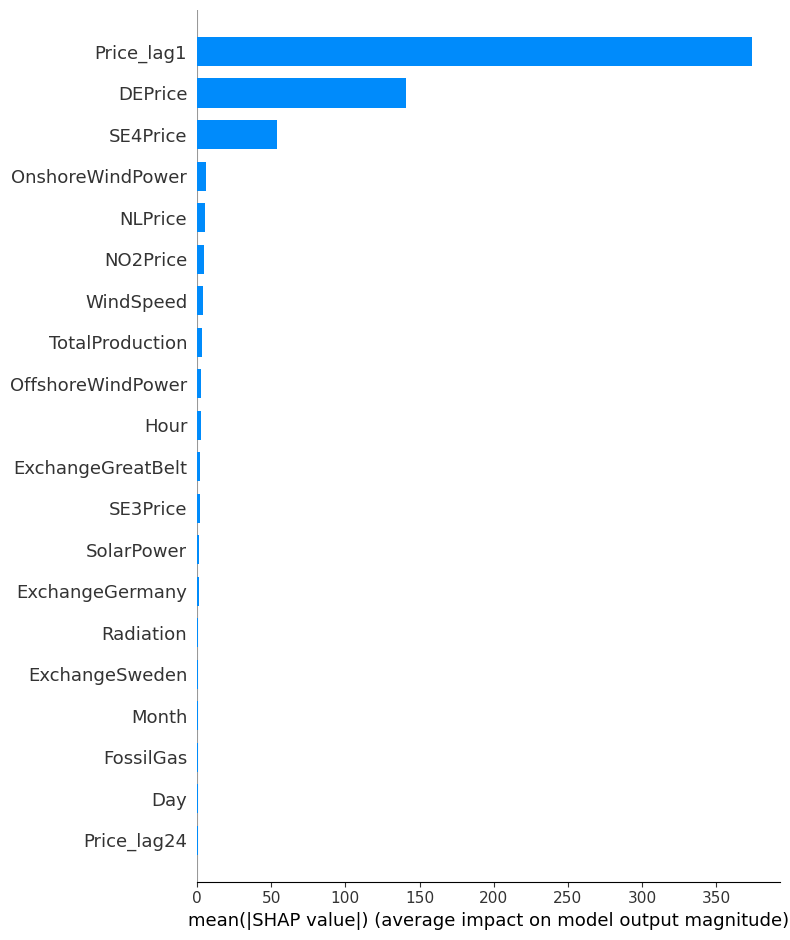

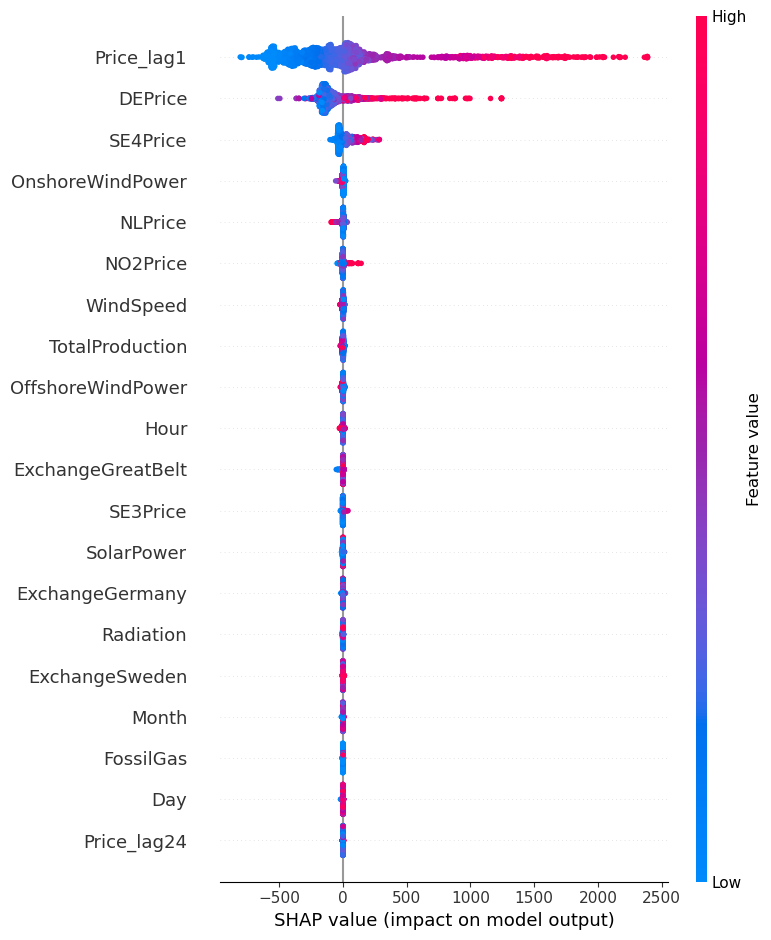

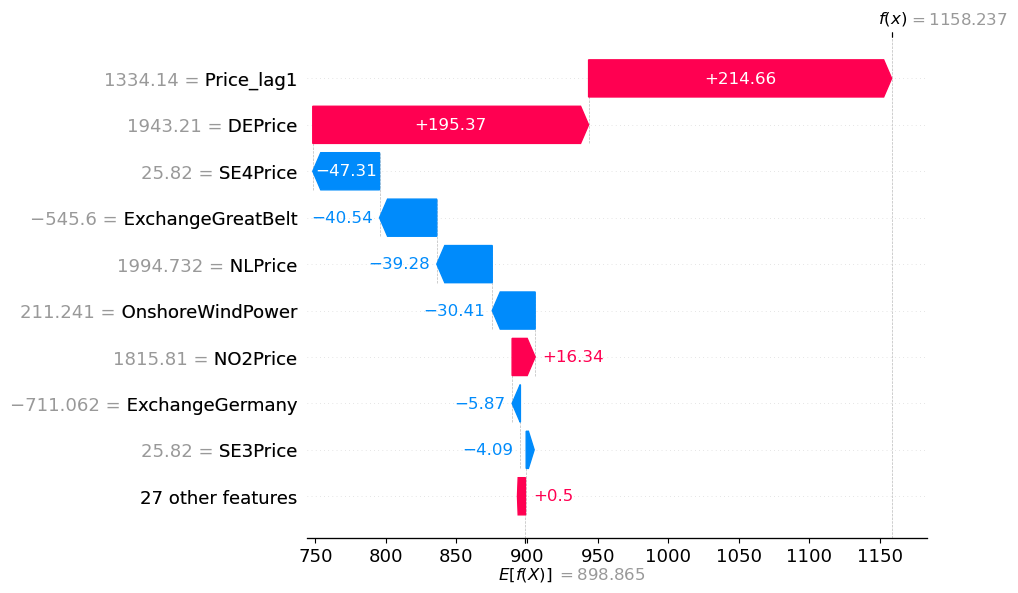

<Figure size 640x480 with 0 Axes>

Available RAM while running SHAP: 3.24 GB

Running SHAP analysis for DK2
Loaded model from disk: c:\Users\Christine\Documents\Python\Speciale_Kode\Shallow learners\Final_eval\Shap\LightGBM_final_model_DK2.joblib
Using fitted LightGBM booster with 200 trees
Available RAM before SHAP: 3.25 GB
Training set size for SHAP: 26304 samples
Number of features: 36

Background sample size (X_bg): 1000
Evaluation sample size (X_eval): 2000
Chunk size: 10
Computing SHAP chunk 1/200 (rows 0:10)...
Computing SHAP chunk 2/200 (rows 10:20)...
Computing SHAP chunk 3/200 (rows 20:30)...
Computing SHAP chunk 4/200 (rows 30:40)...
Computing SHAP chunk 5/200 (rows 40:50)...
Computing SHAP chunk 6/200 (rows 50:60)...
Computing SHAP chunk 7/200 (rows 60:70)...
Computing SHAP chunk 8/200 (rows 70:80)...
Computing SHAP chunk 9/200 (rows 80:90)...
Computing SHAP chunk 10/200 (rows 90:100)...
Computing SHAP chunk 11/200 (rows 100:110)...
Computing SHAP chunk 12/200 (rows 110:120)...
Computing SHAP chunk 13/200 (r

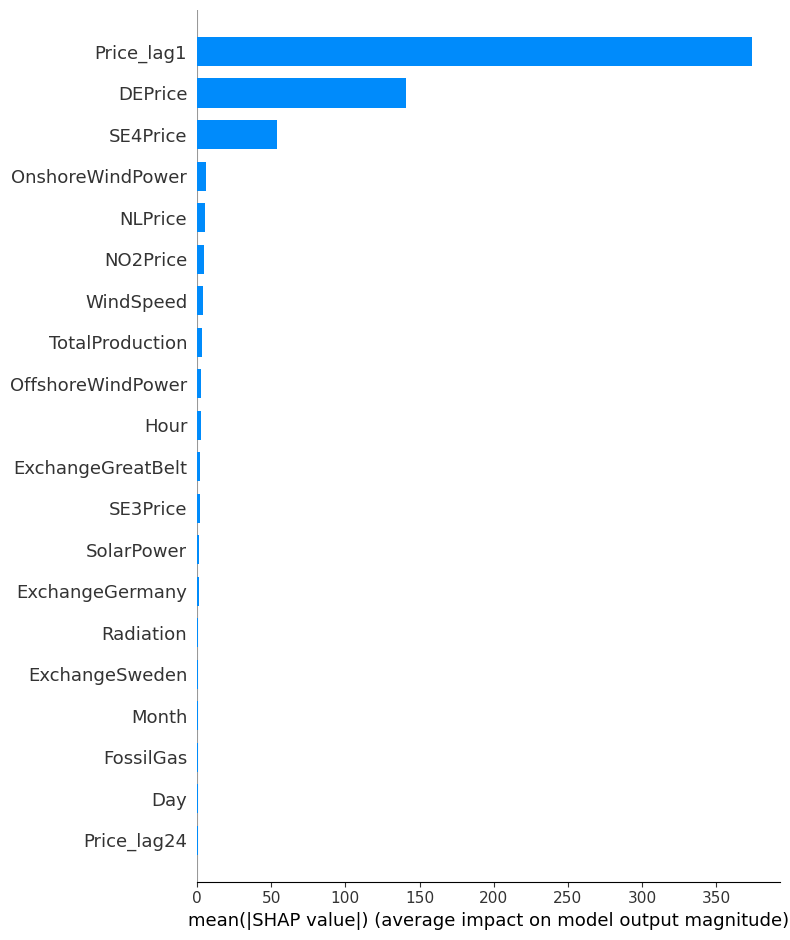

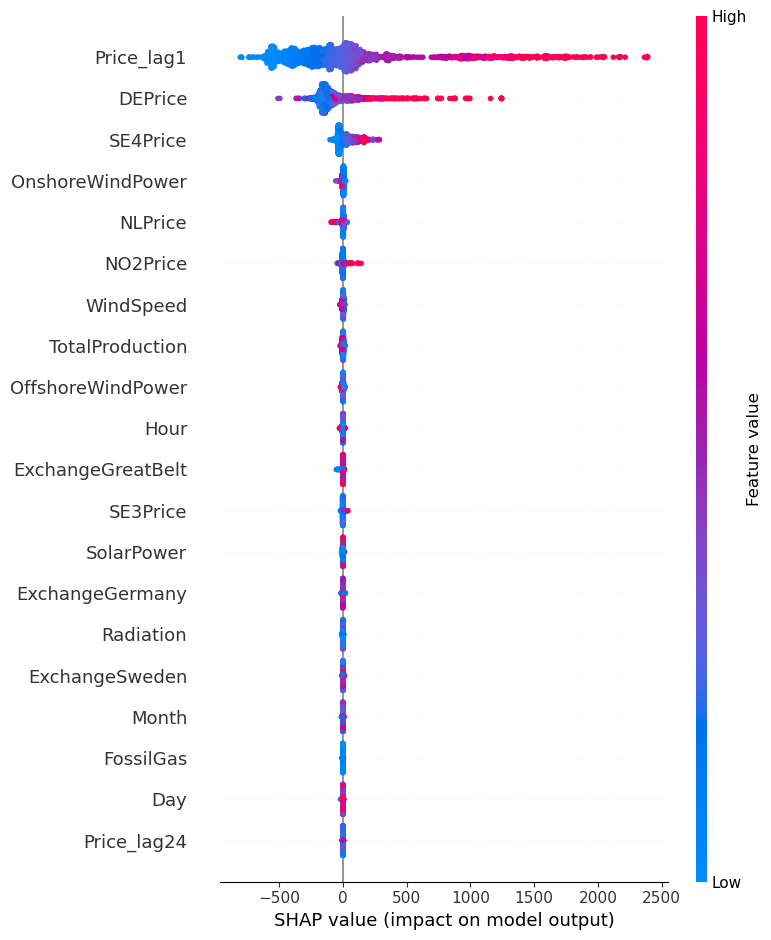

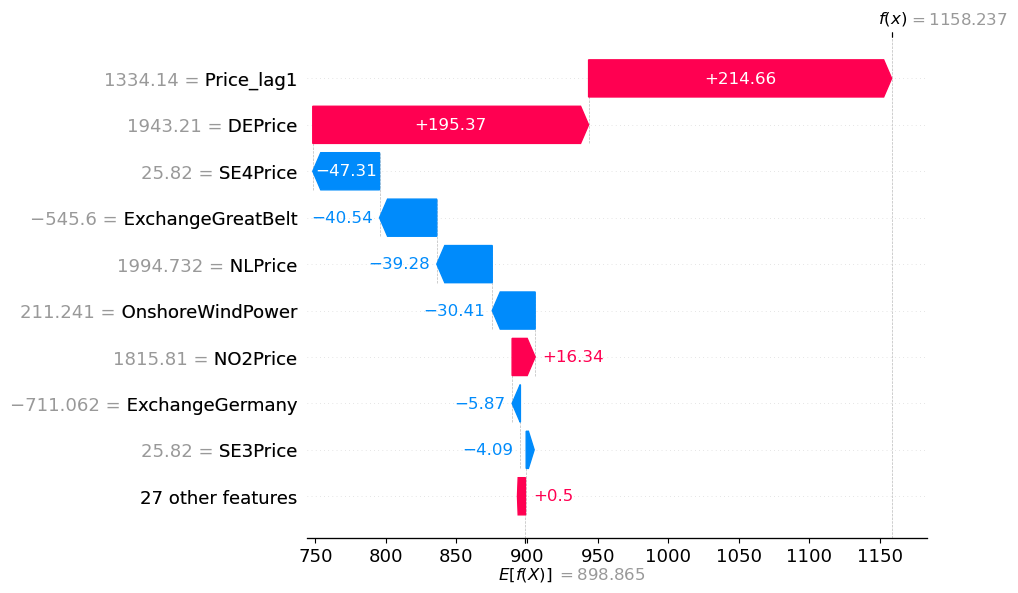

<Figure size 640x480 with 0 Axes>

Available RAM while running SHAP: 3.21 GB
Available RAM after SHAP cleanup: 3.22 GB


In [11]:
import gc
from pathlib import Path
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

# ==========================
# SHAP configuration (easy to tune)
# ==========================
quick_mode = False
eval_size = 2000            # <- Evaluation sample size: number of rows to analyse
bg_size = 1000              # <- Background sample size: used to compute expected values
chunk_size = 10             # <- Lower if memory issues
include_beeswarm = True
include_waterfall = True
joblib_file = "LightGBM_final_model_*.joblib"  # Fallback search pattern in current folder

save_dir = Path(project_root) / "Shallow learners" / "Final_eval" / "Shap" / "plots"
save_dir.mkdir(parents=True, exist_ok=True)

model_name = "LightGBM"

for price_zone in ["DK1", "DK2"]:
    print(f"\n{'='*50}\nRunning SHAP analysis for {price_zone}\n{'='*50}")

    # Auto-load model if it is missing from memory
    if "model" not in globals():
        if "project_root" not in globals():
            raise ValueError("Missing 'project_root'. Run 'Set directory' cell first.")

        model_dir = Path(project_root) / "Shallow learners" / "Final_eval" / "Shap"
        model_path = None

        # Prefer current price_zone if available
        if "price_zone" in globals():
            preferred = model_dir / f"LightGBM_final_model_{price_zone}.joblib"
            if preferred.exists():
                model_path = preferred

        # Otherwise load the newest .joblib that matches the pattern
        if model_path is None:
            candidates = sorted(model_dir.glob(joblib_file), key=lambda p: p.stat().st_mtime, reverse=True)
            if candidates:
                model_path = candidates[0]

        if model_path is None or not model_path.exists():
            raise ValueError(f"No .joblib model found in {model_dir}. Train once or place model file there.")

        model = joblib.load(model_path)
        print(f"Loaded model from disk: {model_path}")

    required_vars = ["dataset", "folds"]
    missing = [v for v in required_vars if v not in globals()]
    if missing:
        raise ValueError(
            f"Missing required variables: {missing}. Run 'Make train and test periods' cell first."
        )

    # Confirm model is fitted (LightGBM exposes booster_ after fit)
    if not hasattr(model, "booster_") or model.booster_ is None:
        raise ValueError("Loaded model is not fitted. Train final model first.")
    print(f"Using fitted LightGBM booster with {model.booster_.num_trees()} trees")

    # Rebuild the same training frame used for fitting
    data = dataset.copy().sort_values("Time").reset_index(drop=True)
    feature_columns = [c for c in data.columns[1:] if c != "Time"]

    first_fold = folds[0]
    train_mask = (data["Time"] >= first_fold["train_start"]) & (data["Time"] <= first_fold["train_end"])
    X_train_shap = data.loc[train_mask, feature_columns].copy()

    if len(X_train_shap) == 0:
        raise ValueError("No rows found for SHAP training slice. Check folds and dataset alignment.")

    # Downcast to reduce memory pressure
    X_train_shap = X_train_shap.astype(np.float32, copy=False)

    mem = psutil.virtual_memory()
    print(f"Available RAM before SHAP: {mem.available / (1024**3):.2f} GB")
    print(f"Training set size for SHAP: {len(X_train_shap)} samples")
    print(f"Number of features: {len(feature_columns)}")

    if quick_mode:
        bg_size = min(20, len(X_train_shap))
        eval_size = min(40, len(X_train_shap))
        chunk_size = 5
    else:
        bg_size = min(bg_size, len(X_train_shap))
        eval_size = min(eval_size, len(X_train_shap))
        chunk_size = max(1, min(chunk_size, eval_size))

    X_bg = shap.sample(X_train_shap, bg_size, random_state=42)
    X_eval = shap.sample(X_train_shap, eval_size, random_state=42)

    print(f"\nBackground sample size (X_bg): {len(X_bg)}")
    print(f"Evaluation sample size (X_eval): {len(X_eval)}")
    print(f"Chunk size: {chunk_size}")

    explainer = shap.TreeExplainer(
        model,
        feature_perturbation="tree_path_dependent",
        model_output="raw"
    )

    # Compute SHAP values in chunks and print progress
    shap_chunks = []
    n_chunks = (len(X_eval) + chunk_size - 1) // chunk_size
    for idx, start in enumerate(range(0, len(X_eval), chunk_size), start=1):
        stop = min(start + chunk_size, len(X_eval))
        print(f"Computing SHAP chunk {idx}/{n_chunks} (rows {start}:{stop})...", flush=True)
        X_chunk = X_eval.iloc[start:stop]
        shap_chunk = explainer.shap_values(
            X_chunk,
            check_additivity=False
        )
        shap_chunks.append(shap_chunk)

    shap_values = np.vstack(shap_chunks)
    gc.collect()

    print("\nSHAP analysis complete.")

    # Global importance
    # Global importance
    plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values, X_eval, plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig(save_dir / f"shap_bar_{model_name}_{price_zone}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    if include_beeswarm:
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_eval, show=False)
        plt.tight_layout()
        plt.savefig(save_dir / f"shap_beeswarm_{model_name}_{price_zone}.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

    if include_waterfall:
        i = 0
        base_value = explainer.expected_value
        if isinstance(base_value, (list, tuple, np.ndarray)):
            base_value = np.array(base_value).reshape(-1)[0]

        plt.figure(figsize=(10, 4))
        shap.plots.waterfall(
            shap.Explanation(
                values=shap_values[i],
                base_values=base_value,
                data=X_eval.iloc[i].values,
                feature_names=X_eval.columns.tolist()
            )
        )
        plt.tight_layout()
        plt.savefig(save_dir / f"shap_waterfall_{model_name}_{price_zone}.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

    mem_while_running = psutil.virtual_memory()
    print(f"Available RAM while running SHAP: {mem_while_running.available / (1024**3):.2f} GB")

    # Cleanup large objects explicitly
    del model
    gc.collect()

mem_after = psutil.virtual_memory()
print(f"Available RAM after SHAP cleanup: {mem_after.available / (1024**3):.2f} GB")

## Linear Regression

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36


c:\Users\Christine\anaconda3\envs\ds809\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.203e+07, tolerance: 1.905e+06
  model = cd_fast.enet_coordinate_descent(


Model trained in 2.67s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 454.400

Average MAE across all weeks in all folds: 383.899

Average SMAPE across all weeks in all folds: 95.487


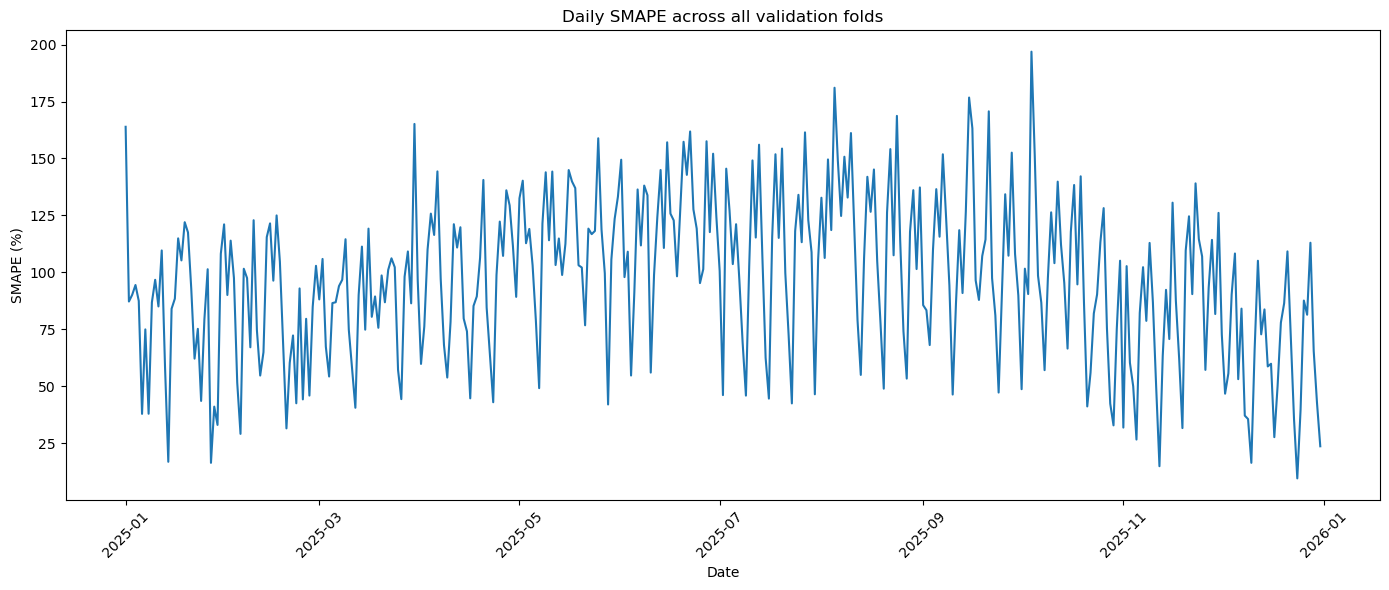

Trained model saved to: c:\Users\Christine\Documents\Python\Speciale_Kode\Shallow learners\Final_eval\Shap\LassoReg_final_model_DK1.joblib


In [12]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Initialize model:
model = Lasso(max_iter=5000)

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    'alpha': 0.0001
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)

# Save model in the same folder as this notebook/script
model_dir = Path(project_root) / "Shallow learners" / "Final_eval" / "Shap"
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / f"LassoReg_final_model_{price_zone}.joblib"

results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "Shap")
base_filename = f"{price_zone}_Lasso_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_Lasso_predictions.csv"),
    index=False,
    decimal=","
)

joblib.dump(model, model_path, compress=3)
print(f"Trained model saved to: {model_path}")

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
Model trained in 0.09s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 437.178

Average MAE across all weeks in all folds: 365.040

Average SMAPE across all weeks in all folds: 84.216


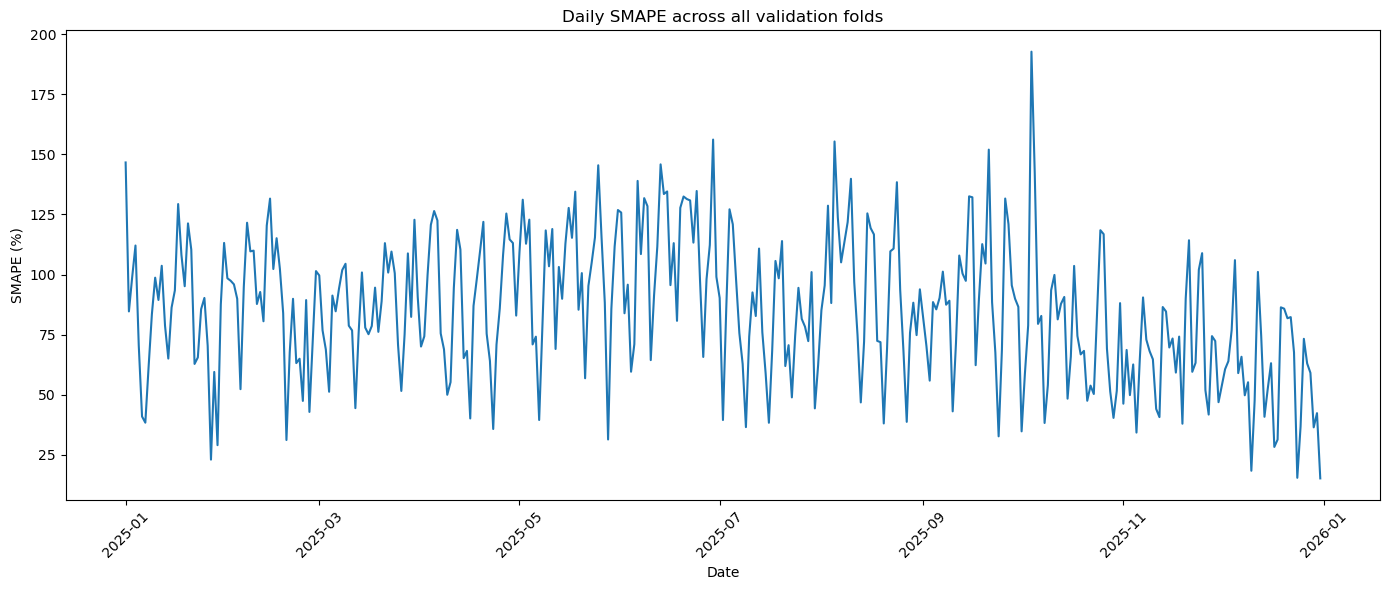

Trained model saved to: c:\Users\Christine\Documents\Python\Speciale_Kode\Shallow learners\Final_eval\Shap\LassoReg_final_model_DK2.joblib


In [13]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Initialize model:
model = Lasso(max_iter=5000)

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    'alpha': 50
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)

# Save model in the same folder as this notebook/script
model_dir = Path(project_root) / "Shallow learners" / "Final_eval" / "Shap"
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / f"LassoReg_final_model_{price_zone}.joblib"

results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "Shap")
base_filename = f"{price_zone}_Lasso_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_Lasso_predictions.csv"),
    index=False,
    decimal=","
)

joblib.dump(model, model_path, compress=3)
print(f"Trained model saved to: {model_path}")


Running SHAP analysis for DK1
Using fitted Lasso model with 36 coefficients
Available RAM before SHAP: 0.93 GB
Training set size for SHAP: 26304 samples
Number of features: 36

Background sample size (X_bg): 1000
Evaluation sample size (X_eval): 2000
Chunk size: 10
Computing SHAP chunk 1/200 (rows 0:10)...
Computing SHAP chunk 2/200 (rows 10:20)...
Computing SHAP chunk 3/200 (rows 20:30)...
Computing SHAP chunk 4/200 (rows 30:40)...
Computing SHAP chunk 5/200 (rows 40:50)...
Computing SHAP chunk 6/200 (rows 50:60)...
Computing SHAP chunk 7/200 (rows 60:70)...
Computing SHAP chunk 8/200 (rows 70:80)...
Computing SHAP chunk 9/200 (rows 80:90)...
Computing SHAP chunk 10/200 (rows 90:100)...
Computing SHAP chunk 11/200 (rows 100:110)...
Computing SHAP chunk 12/200 (rows 110:120)...
Computing SHAP chunk 13/200 (rows 120:130)...
Computing SHAP chunk 14/200 (rows 130:140)...
Computing SHAP chunk 15/200 (rows 140:150)...
Computing SHAP chunk 16/200 (rows 150:160)...
Computing SHAP chunk 17/20

c:\Users\Christine\anaconda3\envs\ds809\lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


Computing SHAP chunk 152/200 (rows 1510:1520)...
Computing SHAP chunk 153/200 (rows 1520:1530)...
Computing SHAP chunk 154/200 (rows 1530:1540)...
Computing SHAP chunk 155/200 (rows 1540:1550)...
Computing SHAP chunk 156/200 (rows 1550:1560)...
Computing SHAP chunk 157/200 (rows 1560:1570)...
Computing SHAP chunk 158/200 (rows 1570:1580)...
Computing SHAP chunk 159/200 (rows 1580:1590)...
Computing SHAP chunk 160/200 (rows 1590:1600)...
Computing SHAP chunk 161/200 (rows 1600:1610)...
Computing SHAP chunk 162/200 (rows 1610:1620)...
Computing SHAP chunk 163/200 (rows 1620:1630)...
Computing SHAP chunk 164/200 (rows 1630:1640)...
Computing SHAP chunk 165/200 (rows 1640:1650)...
Computing SHAP chunk 166/200 (rows 1650:1660)...
Computing SHAP chunk 167/200 (rows 1660:1670)...
Computing SHAP chunk 168/200 (rows 1670:1680)...
Computing SHAP chunk 169/200 (rows 1680:1690)...
Computing SHAP chunk 170/200 (rows 1690:1700)...
Computing SHAP chunk 171/200 (rows 1700:1710)...
Computing SHAP chunk

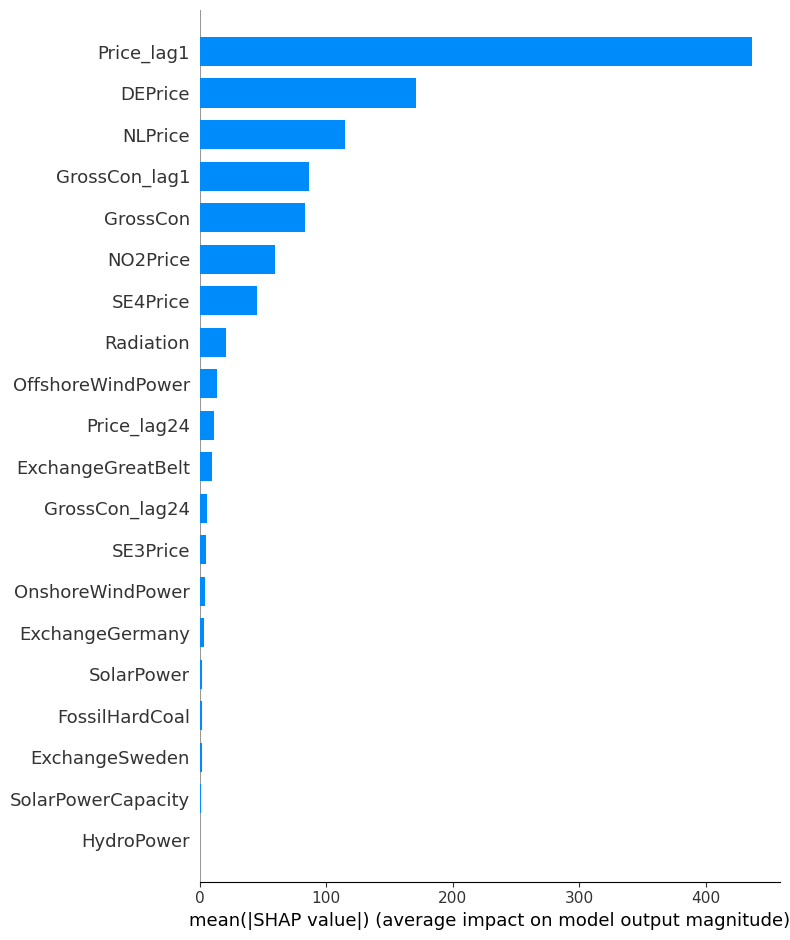

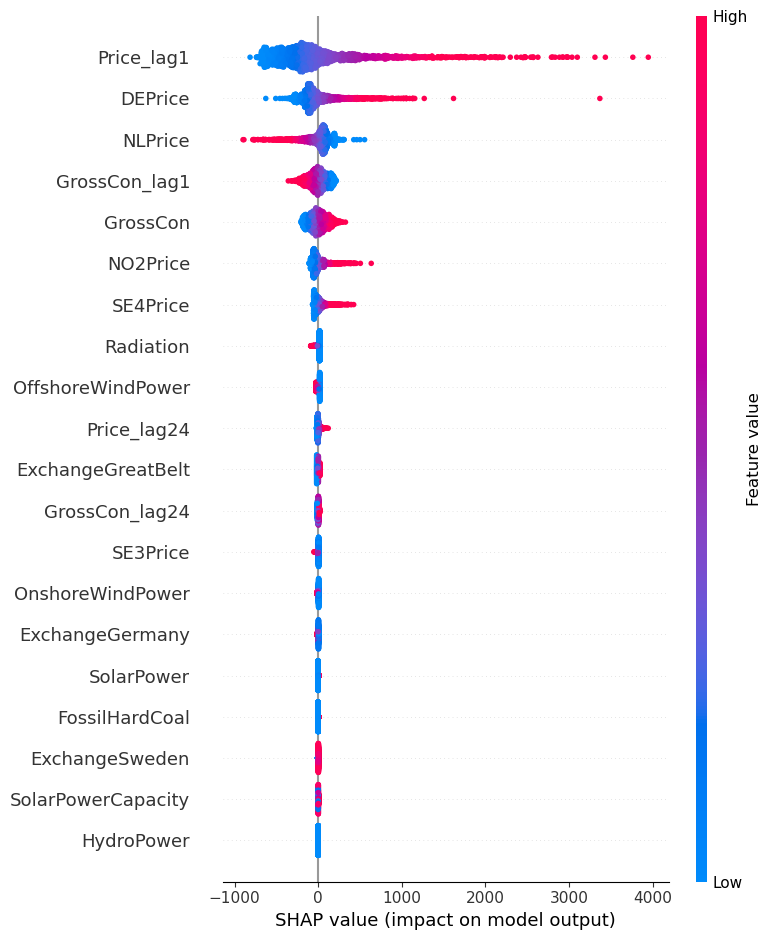

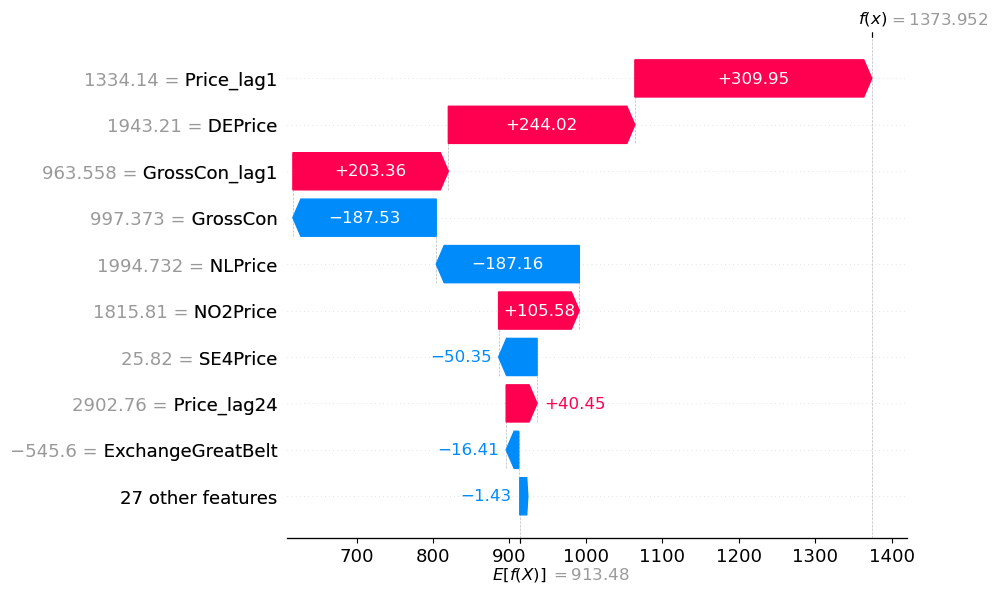

<Figure size 640x480 with 0 Axes>

Available RAM while running SHAP: 1.03 GB

Running SHAP analysis for DK2
Loaded model from disk: c:\Users\Christine\Documents\Python\Speciale_Kode\Shallow learners\Final_eval\Shap\LassoReg_final_model_DK2.joblib
Using fitted Lasso model with 36 coefficients
Available RAM before SHAP: 1.03 GB
Training set size for SHAP: 26304 samples
Number of features: 36

Background sample size (X_bg): 1000
Evaluation sample size (X_eval): 2000
Chunk size: 10
Computing SHAP chunk 1/200 (rows 0:10)...
Computing SHAP chunk 2/200 (rows 10:20)...
Computing SHAP chunk 3/200 (rows 20:30)...
Computing SHAP chunk 4/200 (rows 30:40)...
Computing SHAP chunk 5/200 (rows 40:50)...
Computing SHAP chunk 6/200 (rows 50:60)...
Computing SHAP chunk 7/200 (rows 60:70)...
Computing SHAP chunk 8/200 (rows 70:80)...
Computing SHAP chunk 9/200 (rows 80:90)...
Computing SHAP chunk 10/200 (rows 90:100)...
Computing SHAP chunk 11/200 (rows 100:110)...
Computing SHAP chunk 12/200 (rows 110:120)...
Computing SHAP chunk 13/200 (

c:\Users\Christine\anaconda3\envs\ds809\lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


Computing SHAP chunk 157/200 (rows 1560:1570)...
Computing SHAP chunk 158/200 (rows 1570:1580)...
Computing SHAP chunk 159/200 (rows 1580:1590)...
Computing SHAP chunk 160/200 (rows 1590:1600)...
Computing SHAP chunk 161/200 (rows 1600:1610)...
Computing SHAP chunk 162/200 (rows 1610:1620)...
Computing SHAP chunk 163/200 (rows 1620:1630)...
Computing SHAP chunk 164/200 (rows 1630:1640)...
Computing SHAP chunk 165/200 (rows 1640:1650)...
Computing SHAP chunk 166/200 (rows 1650:1660)...
Computing SHAP chunk 167/200 (rows 1660:1670)...
Computing SHAP chunk 168/200 (rows 1670:1680)...
Computing SHAP chunk 169/200 (rows 1680:1690)...
Computing SHAP chunk 170/200 (rows 1690:1700)...
Computing SHAP chunk 171/200 (rows 1700:1710)...
Computing SHAP chunk 172/200 (rows 1710:1720)...
Computing SHAP chunk 173/200 (rows 1720:1730)...
Computing SHAP chunk 174/200 (rows 1730:1740)...
Computing SHAP chunk 175/200 (rows 1740:1750)...
Computing SHAP chunk 176/200 (rows 1750:1760)...
Computing SHAP chunk

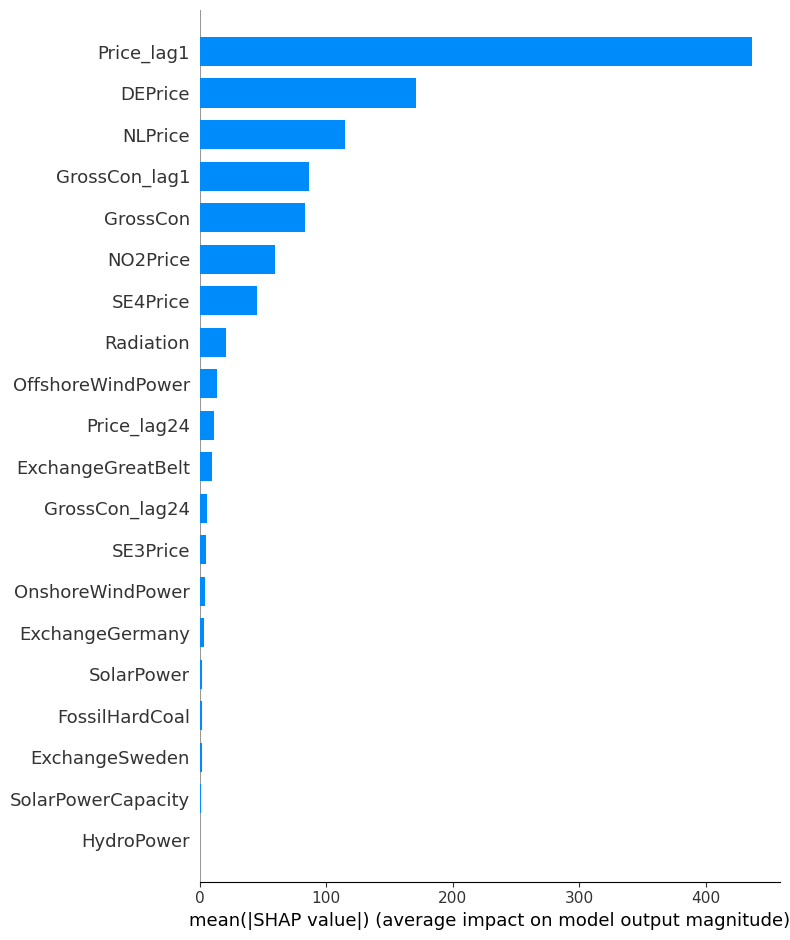

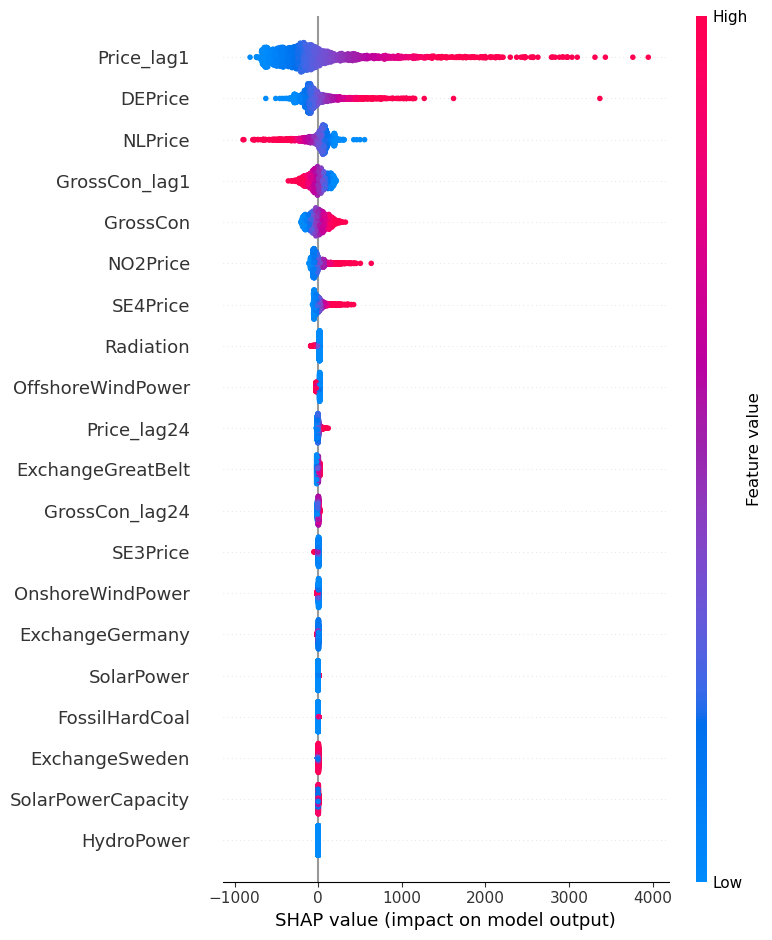

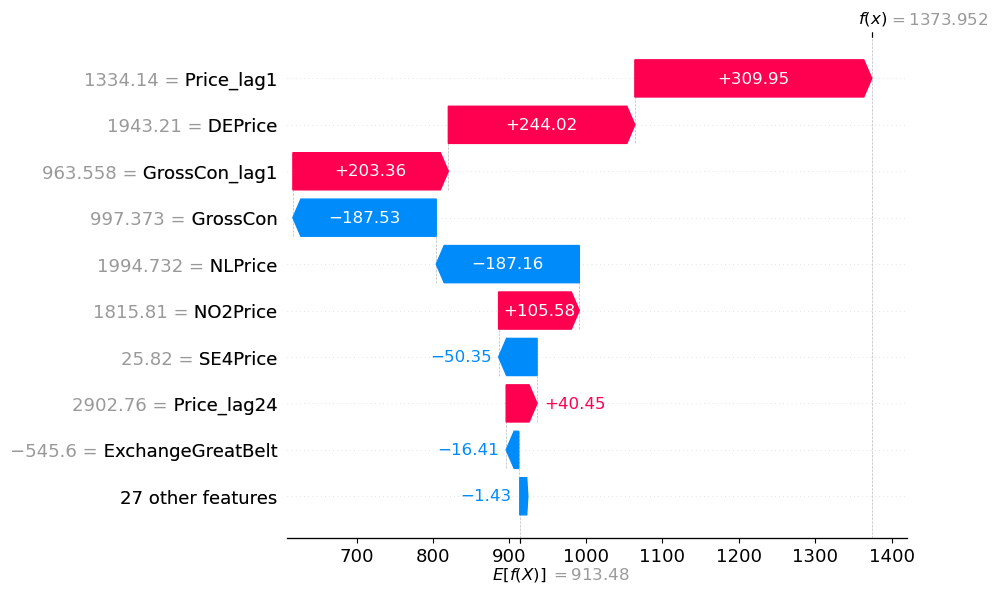

<Figure size 640x480 with 0 Axes>

Available RAM while running SHAP: 0.98 GB
Available RAM after SHAP cleanup: 0.98 GB


In [15]:
import gc
from pathlib import Path
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

# ==========================
# SHAP configuration (easy to tune)
# ==========================
quick_mode = False
eval_size = 2000            # <- Evaluation sample size: number of rows to analyse
bg_size = 1000              # <- Background sample size: used to compute expected values
chunk_size = 10             # <- Lower if memory issues
include_beeswarm = True
include_waterfall = True
joblib_file = "LassoReg_final_model_*.joblib"  # Fallback search pattern in current folder

save_dir = Path(project_root) / "Shallow learners" / "Final_eval" / "Shap" / "plots"
save_dir.mkdir(parents=True, exist_ok=True)

model_name = "LassoReg"

for price_zone in ["DK1", "DK2"]:
    print(f"\n{'='*50}\nRunning SHAP analysis for {price_zone}\n{'='*50}")

    # Auto-load model if it is missing from memory
    if "model" not in globals():
        if "project_root" not in globals():
            raise ValueError("Missing 'project_root'. Run 'Set directory' cell first.")

        model_dir = Path(project_root) / "Shallow learners" / "Final_eval" / "Shap"
        model_path = None

        # Prefer current price_zone if available
        if "price_zone" in globals():
            preferred = model_dir / f"LassoReg_final_model_{price_zone}.joblib"
            if preferred.exists():
                model_path = preferred

        # Otherwise load the newest .joblib that matches the pattern
        if model_path is None:
            candidates = sorted(model_dir.glob(joblib_file), key=lambda p: p.stat().st_mtime, reverse=True)
            if candidates:
                model_path = candidates[0]

        if model_path is None or not model_path.exists():
            raise ValueError(f"No .joblib model found in {model_dir}. Train once or place model file there.")

        model = joblib.load(model_path)
        print(f"Loaded model from disk: {model_path}")

    required_vars = ["dataset", "folds"]
    missing = [v for v in required_vars if v not in globals()]
    if missing:
        raise ValueError(
            f"Missing required variables: {missing}. Run 'Make train and test periods' cell first."
        )

    if not hasattr(model, "coef_") or model.coef_ is None:
        raise ValueError("Loaded model is not fitted. Train final model first.")
    print(f"Using fitted Lasso model with {len(model.coef_)} coefficients")

    # Rebuild the same training frame used for fitting
    data = dataset.copy().sort_values("Time").reset_index(drop=True)
    feature_columns = [c for c in data.columns[1:] if c != "Time"]

    first_fold = folds[0]
    train_mask = (data["Time"] >= first_fold["train_start"]) & (data["Time"] <= first_fold["train_end"])
    X_train_shap = data.loc[train_mask, feature_columns].copy()

    if len(X_train_shap) == 0:
        raise ValueError("No rows found for SHAP training slice. Check folds and dataset alignment.")

    # Downcast to reduce memory pressure
    X_train_shap = X_train_shap.astype(np.float32, copy=False)

    mem = psutil.virtual_memory()
    print(f"Available RAM before SHAP: {mem.available / (1024**3):.2f} GB")
    print(f"Training set size for SHAP: {len(X_train_shap)} samples")
    print(f"Number of features: {len(feature_columns)}")

    if quick_mode:
        bg_size = min(20, len(X_train_shap))
        eval_size = min(40, len(X_train_shap))
        chunk_size = 5
    else:
        bg_size = min(bg_size, len(X_train_shap))
        eval_size = min(eval_size, len(X_train_shap))
        chunk_size = max(1, min(chunk_size, eval_size))

    X_bg = shap.sample(X_train_shap, bg_size, random_state=42)
    X_eval = shap.sample(X_train_shap, eval_size, random_state=42)

    print(f"\nBackground sample size (X_bg): {len(X_bg)}")
    print(f"Evaluation sample size (X_eval): {len(X_eval)}")
    print(f"Chunk size: {chunk_size}")

    explainer = shap.LinearExplainer(model, X_bg, feature_perturbation="interventional")

    # Compute SHAP values in chunks and print progress
    shap_chunks = []
    n_chunks = (len(X_eval) + chunk_size - 1) // chunk_size
    for idx, start in enumerate(range(0, len(X_eval), chunk_size), start=1):
        stop = min(start + chunk_size, len(X_eval))
        print(f"Computing SHAP chunk {idx}/{n_chunks} (rows {start}:{stop})...", flush=True)
        X_chunk = X_eval.iloc[start:stop]
        shap_chunk = explainer.shap_values(X_chunk)
        shap_chunks.append(shap_chunk)

    shap_values = np.vstack(shap_chunks)
    gc.collect()

    print("\nSHAP analysis complete.")

    # Global importance
    plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values, X_eval, plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig(save_dir / f"shap_bar_{model_name}_{price_zone}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    if include_beeswarm:
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_eval, show=False)
        plt.tight_layout()
        plt.savefig(save_dir / f"shap_beeswarm_{model_name}_{price_zone}.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

    if include_waterfall:
        i = 0
        base_value = explainer.expected_value
        if isinstance(base_value, (list, tuple, np.ndarray)):
            base_value = np.array(base_value).reshape(-1)[0]

        plt.figure(figsize=(10, 4))
        shap.plots.waterfall(
            shap.Explanation(
                values=shap_values[i],
                base_values=base_value,
                data=X_eval.iloc[i].values,
                feature_names=X_eval.columns.tolist()
            )
        )
        plt.tight_layout()
        plt.savefig(save_dir / f"shap_waterfall_{model_name}_{price_zone}.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

    mem_while_running = psutil.virtual_memory()
    print(f"Available RAM while running SHAP: {mem_while_running.available / (1024**3):.2f} GB")

    # Cleanup large objects explicitly
    del X_bg, X_eval, X_train_shap, shap_chunks, shap_values
    del model
    gc.collect()

mem_after = psutil.virtual_memory()
print(f"Available RAM after SHAP cleanup: {mem_after.available / (1024**3):.2f} GB")

## XGBoost

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
Model trained in 1.95s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 412.307

Average MAE across all weeks in all folds: 351.408

Average SMAPE across all weeks in all folds: 80.295


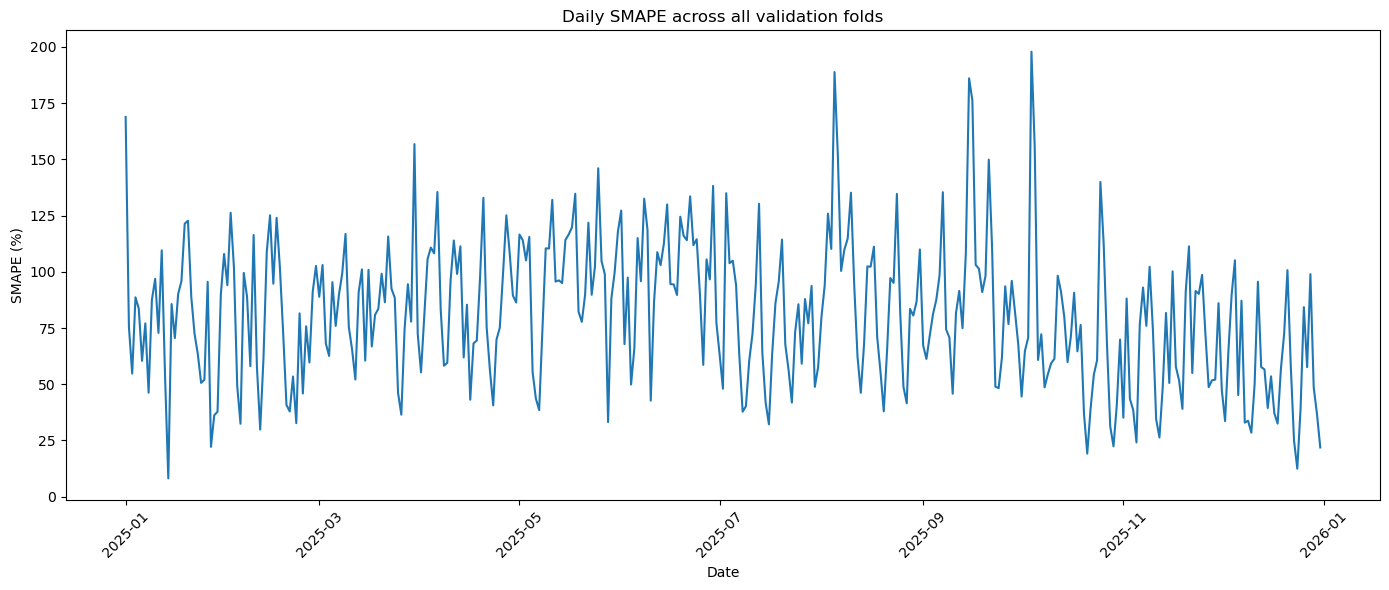

Trained model saved to: c:\Users\Christine\Documents\Python\Speciale_Kode\Shallow learners\Final_eval\Shap\XGBoost_final_model_DK1.joblib


In [16]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from xgboost import XGBRegressor

# Initialize model:
model = XGBRegressor()

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "max_depth": 5,
    "learning_rate": 0.05,
    "n_estimators": 400,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)

# Save model in the same folder as this notebook/script
model_dir = Path(project_root) / "Shallow learners" / "Final_eval" / "Shap"
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / f"XGBoost_final_model_{price_zone}.joblib"

results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "Shap")
base_filename = f"{price_zone}_XGBoost_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_XGBoost_predictions.csv"),
    index=False,
    decimal=","
)

joblib.dump(model, model_path, compress=3)
print(f"Trained model saved to: {model_path}")

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
Model trained in 2.74s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 425.073

Average MAE across all weeks in all folds: 359.921

Average SMAPE across all weeks in all folds: 77.567


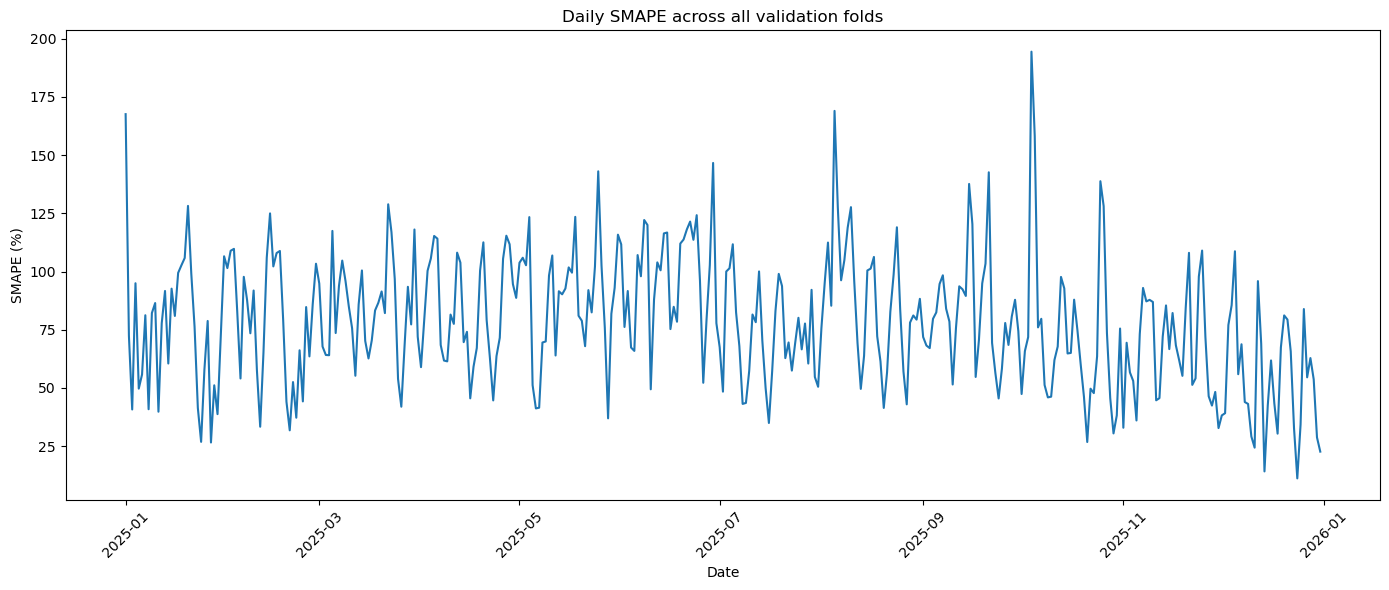

Trained model saved to: c:\Users\Christine\Documents\Python\Speciale_Kode\Shallow learners\Final_eval\Shap\XGBoost_final_model_DK2.joblib


In [17]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from xgboost import XGBRegressor

# Initialize model:
model = XGBRegressor()

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "max_depth": 7,
    "learning_rate": 0.05,
    "n_estimators": 400,
    "subsample": 1.0,
    "colsample_bytree": 0.7,
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)

# Save model in the same folder as this notebook/script
model_dir = Path(project_root) / "Shallow learners" / "Final_eval" / "Shap"
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / f"XGBoost_final_model_{price_zone}.joblib"

results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "Shap")
base_filename = f"{price_zone}_XGBoost_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_XGBoost_predictions.csv"),
    index=False,
    decimal=","
)

joblib.dump(model, model_path, compress=3)
print(f"Trained model saved to: {model_path}")


Running SHAP analysis for DK1
[17:09:57] WARNING: D:\bld\xgboost-split_1700181111005\work\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.

Loaded model from disk: c:\Users\Christine\Documents\Python\Speciale_Kode\Shallow learners\Final_eval\Shap\XGBoost_final_model_DK1.joblib
Using fitted XGBoost model with 400 trees
Available RAM before SHAP: 1.86 GB
Training set size for SHAP: 26304 samples
Number of features: 36

Background sample size (X_bg): 1000
Evaluation sample size (X_eval): 2000
Chunk size: 10
Computing SHAP chunk 1/200 (rows 0:10)...
Computing SHAP chunk 2/200 (rows 10:20)...
Computing SHAP chunk 3/200 (rows 20:30)...
Computing

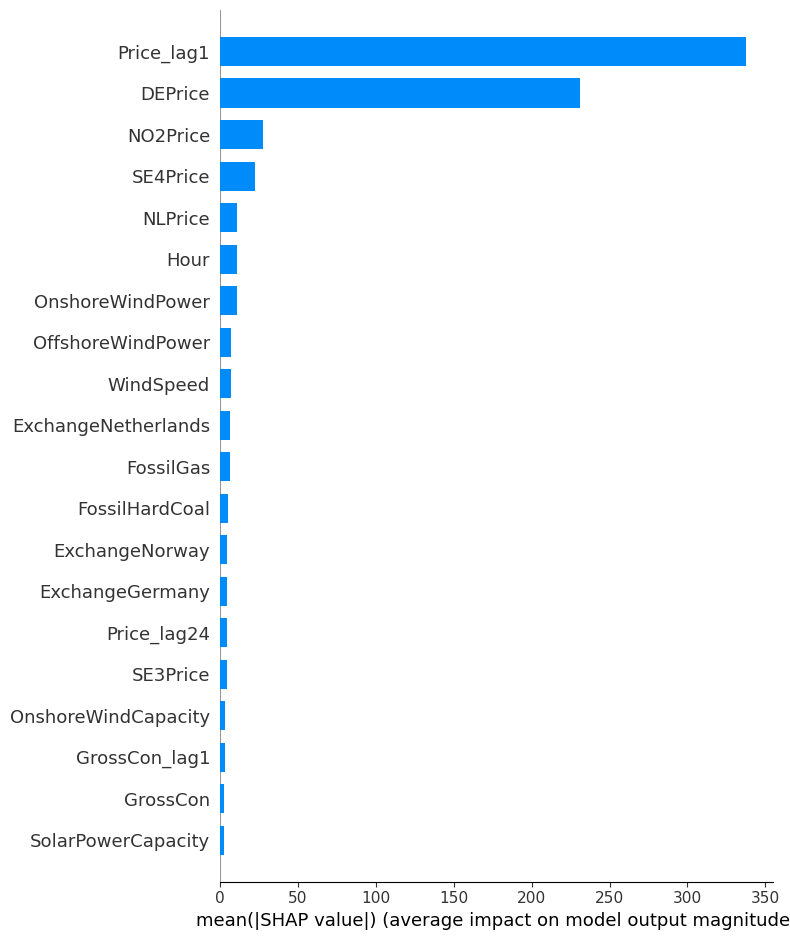

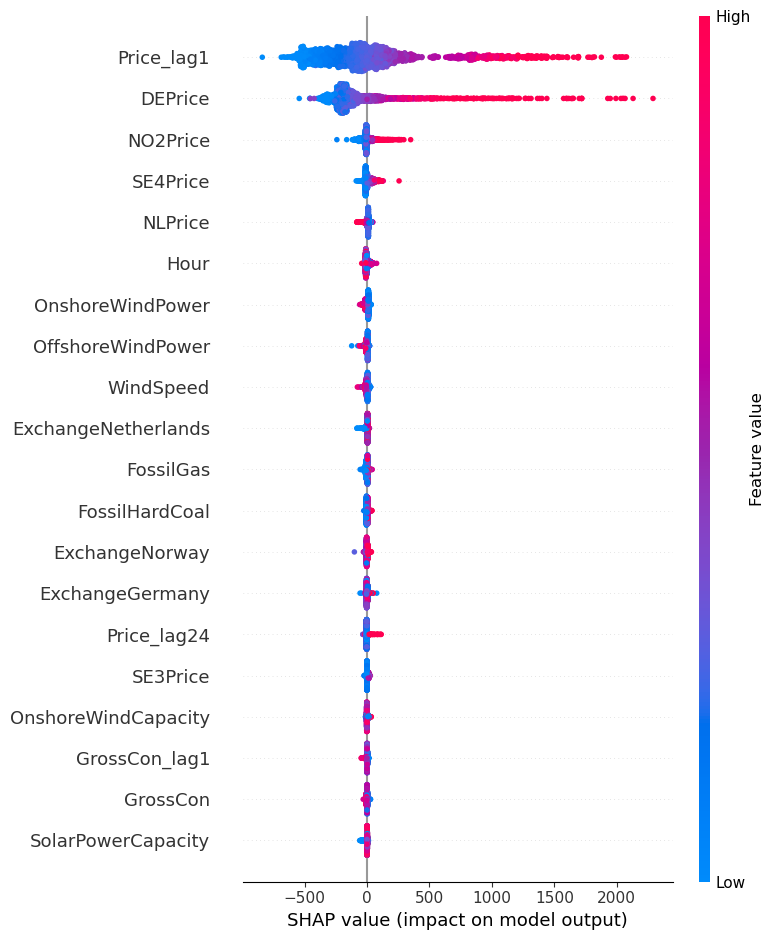

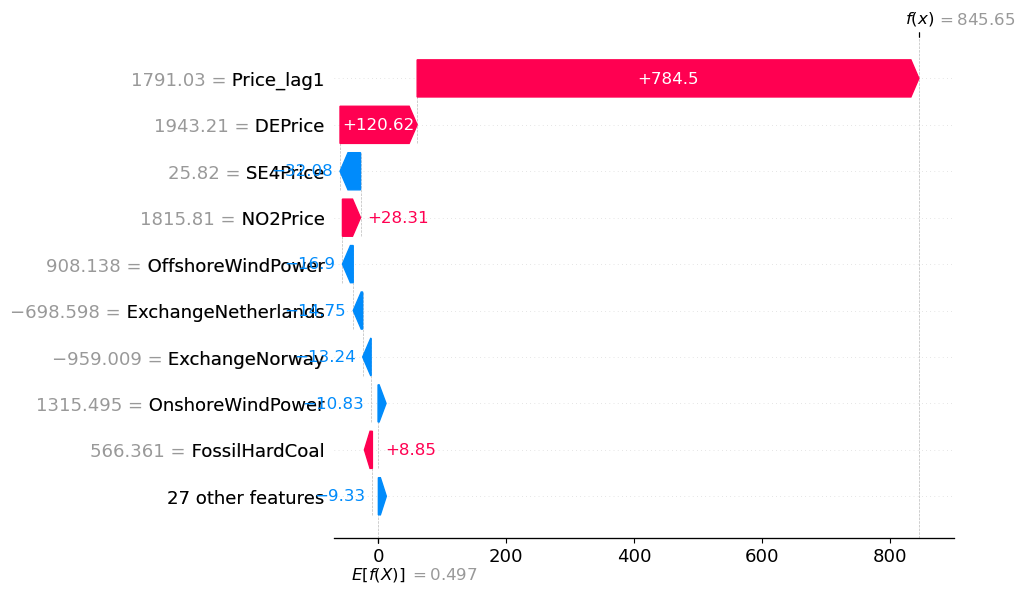

<Figure size 640x480 with 0 Axes>

Available RAM while running SHAP: 1.83 GB

Running SHAP analysis for DK2
[17:10:04] WARNING: D:\bld\xgboost-split_1700181111005\work\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.

Loaded model from disk: c:\Users\Christine\Documents\Python\Speciale_Kode\Shallow learners\Final_eval\Shap\XGBoost_final_model_DK2.joblib
Using fitted XGBoost model with 400 trees
Available RAM before SHAP: 1.83 GB
Training set size for SHAP: 26304 samples
Number of features: 36

Background sample size (X_bg): 1000
Evaluation sample size (X_eval): 2000
Chunk size: 10
Computing SHAP chunk 1/200 (rows 0:10)...
Computing SHAP chunk 2/200 (rows 10:20)...
Computing 

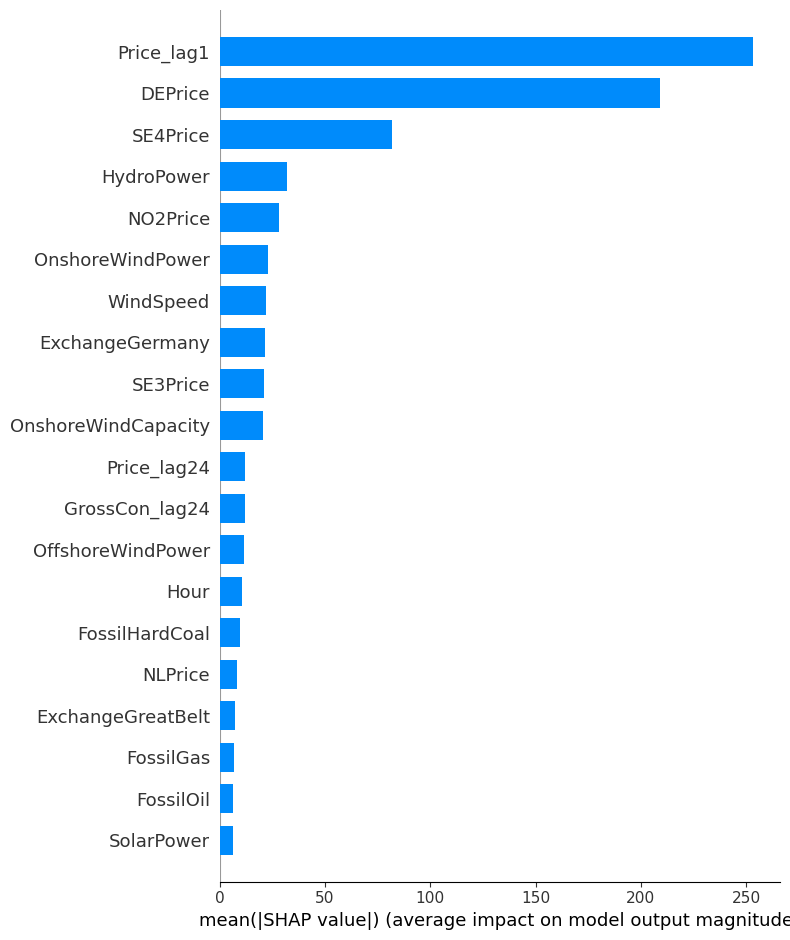

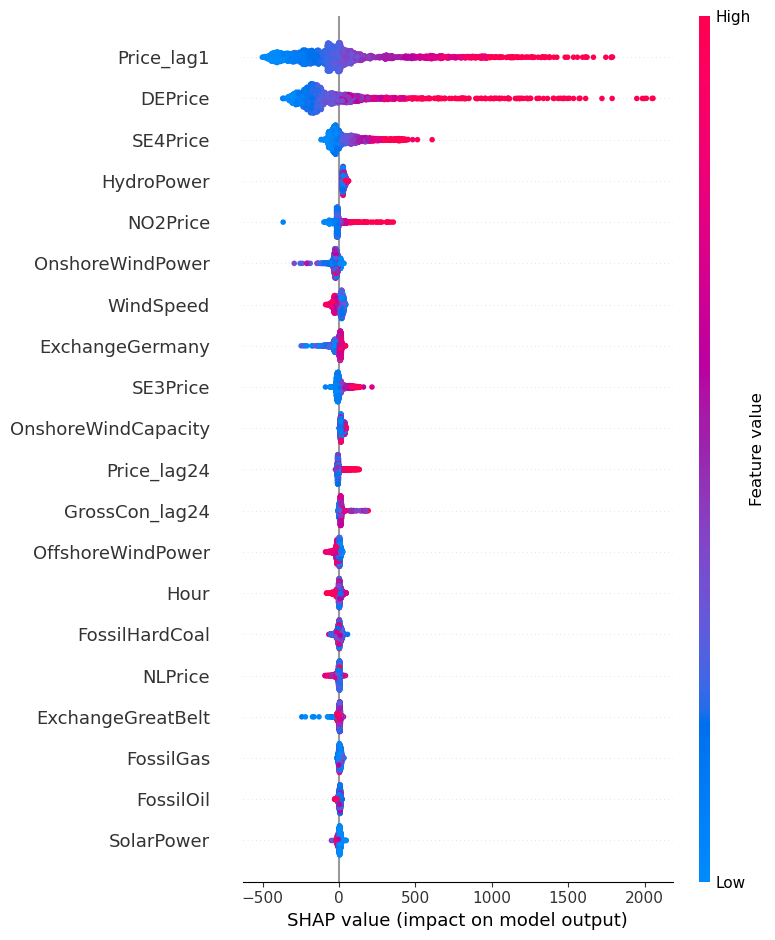

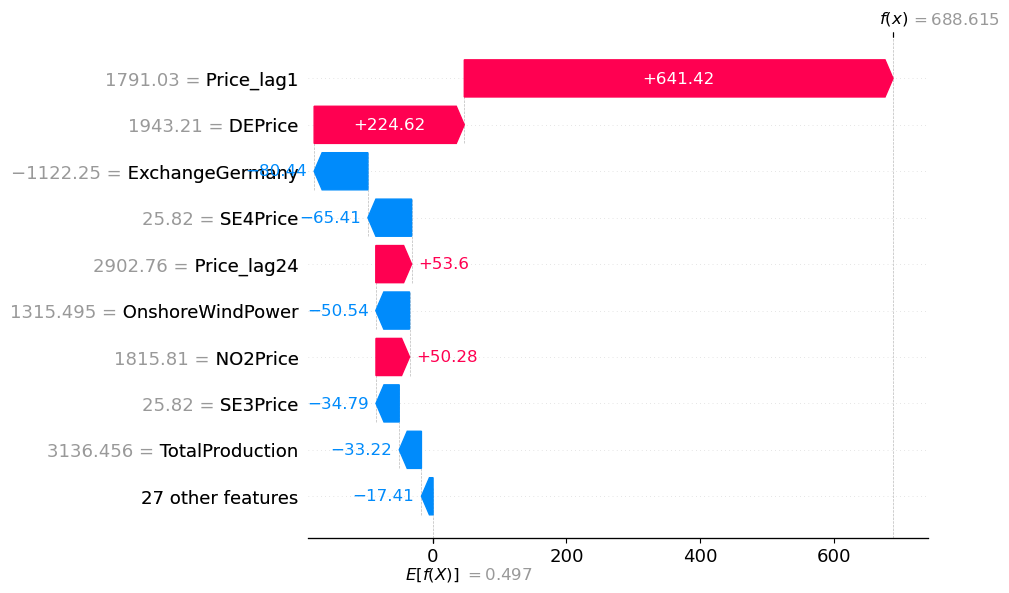

<Figure size 640x480 with 0 Axes>

Available RAM while running SHAP: 1.79 GB
Available RAM after SHAP cleanup: 1.80 GB


In [7]:
import gc
from pathlib import Path
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

# ==========================
# SHAP configuration (easy to tune)
# ==========================
quick_mode = False
eval_size = 2000            # <- Evaluation sample size: number of rows to analyse
bg_size = 1000              # <- Background sample size: used to compute expected values
chunk_size = 10             # <- Lower if memory issues
include_beeswarm = True
include_waterfall = True
joblib_file = "XGBoost_final_model_*.joblib"  # Fallback search pattern in current folder

save_dir = Path(project_root) / "Shallow learners" / "Final_eval" / "Shap" / "plots"
save_dir.mkdir(parents=True, exist_ok=True)

model_name = "XGBoost"

for price_zone in ["DK1", "DK2"]:
    print(f"\n{'='*50}\nRunning SHAP analysis for {price_zone}\n{'='*50}")

    # Auto-load model if it is missing from memory
    if "model" not in globals():
        if "project_root" not in globals():
            raise ValueError("Missing 'project_root'. Run 'Set directory' cell first.")

        model_dir = Path(project_root) / "Shallow learners" / "Final_eval" / "Shap"
        model_path = None

        # Prefer current price_zone if available
        if "price_zone" in globals():
            preferred = model_dir / f"XGBoost_final_model_{price_zone}.joblib"
            if preferred.exists():
                model_path = preferred

        # Otherwise load the newest .joblib that matches the pattern
        if model_path is None:
            candidates = sorted(model_dir.glob(joblib_file), key=lambda p: p.stat().st_mtime, reverse=True)
            if candidates:
                model_path = candidates[0]

        if model_path is None or not model_path.exists():
            raise ValueError(f"No .joblib model found in {model_dir}. Train once or place model file there.")

        model = joblib.load(model_path)
        print(f"Loaded model from disk: {model_path}")

    required_vars = ["dataset", "folds"]
    missing = [v for v in required_vars if v not in globals()]
    if missing:
        raise ValueError(
            f"Missing required variables: {missing}. Run 'Make train and test periods' cell first."
        )

    try:
        model.get_booster()
    except Exception:
        raise ValueError("Loaded model is not fitted. Train final model first.")
    print(f"Using fitted XGBoost model with {model.get_booster().num_boosted_rounds()} trees")

    # Rebuild the same training frame used for fitting
    data = dataset.copy().sort_values("Time").reset_index(drop=True)
    feature_columns = [c for c in data.columns[1:] if c != "Time"]

    first_fold = folds[0]
    train_mask = (data["Time"] >= first_fold["train_start"]) & (data["Time"] <= first_fold["train_end"])
    X_train_shap = data.loc[train_mask, feature_columns].copy()

    if len(X_train_shap) == 0:
        raise ValueError("No rows found for SHAP training slice. Check folds and dataset alignment.")

    # Downcast to reduce memory pressure
    X_train_shap = X_train_shap.astype(np.float32, copy=False)

    mem = psutil.virtual_memory()
    print(f"Available RAM before SHAP: {mem.available / (1024**3):.2f} GB")
    print(f"Training set size for SHAP: {len(X_train_shap)} samples")
    print(f"Number of features: {len(feature_columns)}")

    if quick_mode:
        bg_size = min(20, len(X_train_shap))
        eval_size = min(40, len(X_train_shap))
        chunk_size = 5
    else:
        bg_size = min(bg_size, len(X_train_shap))
        eval_size = min(eval_size, len(X_train_shap))
        chunk_size = max(1, min(chunk_size, eval_size))

    X_bg = shap.sample(X_train_shap, bg_size, random_state=42)
    X_eval = shap.sample(X_train_shap, eval_size, random_state=42)

    print(f"\nBackground sample size (X_bg): {len(X_bg)}")
    print(f"Evaluation sample size (X_eval): {len(X_eval)}")
    print(f"Chunk size: {chunk_size}")

    import json
    booster = model.get_booster()
    raw_config = booster.save_config()

    # Strip brackets from base_score value before parsing
    import re
    raw_config = re.sub(r'"base_score":\s*"\[([^\]]+)\]"', r'"base_score": "\1"', raw_config)

    cfg = json.loads(raw_config)
    cfg["learner"]["learner_model_param"]["base_score"] = "0.5"
    booster.load_config(json.dumps(cfg))

    explainer = shap.TreeExplainer(
        booster,
        feature_perturbation="tree_path_dependent",
        model_output="raw"
    )

    # Compute SHAP values in chunks and print progress
    shap_chunks = []
    n_chunks = (len(X_eval) + chunk_size - 1) // chunk_size
    for idx, start in enumerate(range(0, len(X_eval), chunk_size), start=1):
        stop = min(start + chunk_size, len(X_eval))
        print(f"Computing SHAP chunk {idx}/{n_chunks} (rows {start}:{stop})...", flush=True)
        X_chunk = X_eval.iloc[start:stop]
        shap_chunk = explainer.shap_values(
            X_chunk,
            check_additivity=False
        )
        shap_chunks.append(shap_chunk)

    shap_values = np.vstack(shap_chunks)
    gc.collect()

    print("\nSHAP analysis complete.")

    # Global importance
    plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values, X_eval, plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig(save_dir / f"shap_bar_{model_name}_{price_zone}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    if include_beeswarm:
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_eval, show=False)
        plt.tight_layout()
        plt.savefig(save_dir / f"shap_beeswarm_{model_name}_{price_zone}.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

    if include_waterfall:
        i = 0
        base_value = explainer.expected_value
        if isinstance(base_value, (list, tuple, np.ndarray)):
            base_value = np.array(base_value).reshape(-1)[0]

        plt.figure(figsize=(10, 4))
        shap.plots.waterfall(
            shap.Explanation(
                values=shap_values[i],
                base_values=base_value,
                data=X_eval.iloc[i].values,
                feature_names=X_eval.columns.tolist()
            )
        )
        plt.tight_layout()
        plt.savefig(save_dir / f"shap_waterfall_{model_name}_{price_zone}.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

    mem_while_running = psutil.virtual_memory()
    print(f"Available RAM while running SHAP: {mem_while_running.available / (1024**3):.2f} GB")

    # Cleanup large objects explicitly
    del X_bg, X_eval, X_train_shap, shap_chunks, shap_values
    del model
    gc.collect()

mem_after = psutil.virtual_memory()
print(f"Available RAM after SHAP cleanup: {mem_after.available / (1024**3):.2f} GB")